
# <font color="red"> Cuaderno 6. Introducción al Procesamiento Digital de Imágenes con Python </font>

## <font color="blue"> Por Alfredo Alfredo Diaz </font>


El procesamiento de imágenes es una disciplina dentro del campo de la IT que se encarga de la manipulación, análisis y transformación de imágenes digitales. En el contexto de la visión por computadora y el aprendizaje automático, se emplean diversas técnicas para convertir imágenes en representaciones que pueden ser entendidas y procesadas por algoritmos.

Definición de Imagen Digital

Una imagen digital es una representación discreta de una imagen analógica, en la que tanto las coordenadas espaciales como la intensidad de los píxeles han sido "muestreadas" y "cuantizadas". Esto significa que, en lugar de tener una imagen continua, tenemos una matriz de números que representan la intensidad de los píxeles en cada coordenada.

En la imagen se puede apreciar que cada pixel representa un punto en la imagen y este a su vez tiene un valor discreto. El archivo o variable es un arreglo de 2D, con todos los valores de los pixeles.

![matrices](https://ai.stanford.edu/~syyeung/cvweb/Pictures1/imagematrix.png)

Entonces, una imagen digital no es más que una matriz de números, donde cada uno de ellos se denomina píxel. Dependiendo del espacio de color usado, el significado de estos valores varía.


##Tipos de Imágenes

**Imagen de Intensidad (Escala de Grises):** Cada píxel en la imagen tiene un solo valor que representa la
intensidad de la luz (generalmente en un rango de 0 a 255 para imágenes de 8 bits).

**Imagen Binaria (Blaco y Negro):** Una imagen que tiene solo dos valores posibles por píxel (0 y 1), representando blanco y negro.

**Imagen en Color:** Cada píxel se representa con tres valores de intensidad, uno para cada canal de color (RGB: Rojo, Verde y Azul).

##Explicación de imágenes como arreglos 1D, 2D y 3D:

Las imágenes pueden representarse de diferentes maneras en función de sus dimensiones. Cuando se trata de imágenes digitales, las representaciones más comunes son en forma de arreglos multidimensionales, es decir, matrices de números que codifican los valores de los píxeles de la imagen. Aquí vamos a explicar cómo una imagen puede ser representada como un arreglo de una, dos o tres dimensiones.

![imagen](https://aprendeconalf.es/docencia/python/manual/img/arrays.png)

##Módulos de Python para Procesamiento de Imágenes

Los módulos más utilizados para procesamiento de imágenes en Python incluyen:

**OpenCV (cv2):** Para operaciones de visión por computadora de bajo nivel, como leer, escribir, modificar y analizar imágenes.

**NumPy:** Para manejar y manipular arrays que representan imágenes.

**Matplotlib:** Para visualizar imágenes y realizar gráficos.

**Pillow (PIL):** Para operaciones de alto nivel en imágenes como transformaciones o filtrado

En Python, existen varias bibliotecas potentes que facilitan el procesamiento de imágenes, como [OpenCV](http://docs.opencv.org/3.0-beta/doc/py_tutorials/py_tutorials.html), [SciKit-Image] (http://scikit-image.org/) y [Pillow](http://python-pillow.org/).

El objetivo de este cuaderno es comprender los fundamentos de algunas técnicas simples de procesamiento de imágenes y adentrarnos a las convoluciones o filtros para aplicarlas en las redes convolucionales,  que serán necesarias para aprender procesamiento de imagenes con Deep Learning.




##Instalación de paquetes

En Anaconda, para instalar OpenCV, por ejemplo, puedes usar el siguiente comando en el terminal:


```python
conda install -c conda-forge opencv
```

En Google Colab, puedes instalar estos paquetes usando pip:

```python
!pip install opencv-python numpy matplotlib pillow
```

Enlace de un powerpoint complementario
https://github.com/adiacla/bigdata/raw/refs/heads/master/Interpolacion%20de%20color.pptx

##Importación de Módulos
Una vez instalados los paquetes, puedes importarlos de la siguiente manera en tu script de Python:


In [1]:
import cv2 as cv                  # open vision library OpenCV
import numpy as np                # funciones numéricas (arrays, matrices, etc.)
import matplotlib.pyplot as plt   # funciones para representación gráfica
from PIL import Image
from ipywidgets import interact, FloatSlider
import pandas as pd
#from google.colab.patches import cv2_imshow
#la anterior línea solo usa para Google Colab.

##Lectura, Visualización y Escritura de Imágenes
**Leer una Imagen**
Para leer una imagen con OpenCV, puedes utilizar la función cv.imread(), que carga una imagen en formato de matriz.

In [2]:
#Descargar de https://github.com/adiacla/bigdata/blob/master/logo.jpg
!curl -O https://raw.githubusercontent.com/adiacla/bigdata/master/logo.jpg
!curl -O https://raw.githubusercontent.com/adiacla/bigdata/master/motinor.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  7358  100  7358    0     0   124k      0 --:--:-- --:--:-- --:--:--  126k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  753k  100  753k    0     0  11.0M      0 --:--:-- --:--:-- --:--:-- 11.1M


In [3]:
import matplotlib.image as mpimg


# Cargar imagen
img = mpimg.imread("motinor.jpg")

# Función para mostrar zoom
def mostrar_zoom(zoom=1.0, cx=0.5, cy=0.5):
    h, w = img.shape[:2]
    zoom = max(zoom, 1.0)  # evitar valores menores que 1
    crop_w, crop_h = int(w/zoom), int(h/zoom)

    # centro del recorte
    cx, cy = int(cx*w), int(cy*h)

    # coordenadas del recorte
    x1 = max(0, cx - crop_w//2)
    y1 = max(0, cy - crop_h//2)
    x2 = min(w, cx + crop_w//2)
    y2 = min(h, cy + crop_h//2)

    # recortar
    recorte = img[y1:y2, x1:x2]

    # mostrar imagen
    plt.figure(figsize=(6,6))
    plt.imshow(recorte)
    plt.axis("off")
    plt.show()

# Widgets interactivos
interact(
    mostrar_zoom,
    zoom=FloatSlider(value=1.0, min=1, max=5, step=0.1),
    cx=FloatSlider(value=0.5, min=0, max=1, step=0.01),
    cy=FloatSlider(value=0.5, min=0, max=1, step=0.01)
)


interactive(children=(FloatSlider(value=1.0, description='zoom', max=5.0, min=1.0), FloatSlider(value=0.5, des…

<function __main__.mostrar_zoom(zoom=1.0, cx=0.5, cy=0.5)>

In [ ]:
#Cargar la imagen 'logo.jpg' usando OpenCV, recuerde que lo muestra en BGR o en RGB
img = cv.imread('logo.jpg')

 # mostrar imagen


img

array([[[ 79, 192, 249],
        [  0, 169, 235],
        [  0, 166, 251],
        ...,
        [  3, 167, 249],
        [  3, 169, 246],
        [ 86, 192, 245]],

       [[ 79, 192, 249],
        [  0, 169, 235],
        [  0, 166, 251],
        ...,
        [  3, 167, 249],
        [  3, 169, 246],
        [ 86, 192, 245]],

       [[ 79, 192, 249],
        [  0, 169, 235],
        [  0, 166, 251],
        ...,
        [  3, 167, 249],
        [  3, 169, 246],
        [ 86, 192, 245]],

       ...,

       [[ 79, 192, 249],
        [  0, 169, 235],
        [  0, 166, 251],
        ...,
        [  3, 167, 249],
        [  3, 169, 246],
        [ 86, 192, 245]],

       [[ 79, 192, 249],
        [  0, 169, 235],
        [  0, 166, 251],
        ...,
        [  3, 167, 249],
        [  3, 169, 246],
        [ 86, 192, 245]],

       [[ 79, 192, 249],
        [  0, 169, 235],
        [  0, 166, 251],
        ...,
        [  3, 167, 249],
        [  3, 169, 246],
        [ 86, 192, 245]]

In [5]:
# Convertir cada canal de color (B, G, R) de la imagen a un DataFrame de pandas
img_df_B = pd.DataFrame(img[:, :, 0])
img_df_G = pd.DataFrame(img[:, :, 1])
img_df_R = pd.DataFrame(img[:, :, 2])


In [6]:
# Mostrar el DataFrame correspondiente al canal azul (B) de la imagen
img_df_B

,0,1,2,3,4,5,6,7,8,9,...,215,216,217,218,219,220,221,222,223,224
0,79,0,0,24,5,2,7,0,1,1,...,1,3,3,3,3,3,3,3,3,86
1,79,0,0,24,5,2,7,0,1,1,...,1,3,3,3,3,3,3,3,3,86
2,79,0,0,24,5,2,7,0,1,1,...,1,3,3,3,3,3,3,3,3,86
3,79,0,0,24,5,2,7,0,1,1,...,1,3,3,3,3,3,3,3,3,86
4,79,0,0,24,5,2,7,0,1,1,...,1,3,3,3,3,3,3,3,3,86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,79,0,0,24,5,2,7,0,1,1,...,1,3,3,3,3,3,3,3,3,86
221,79,0,0,24,5,2,7,0,1,1,...,1,3,3,3,3,3,3,3,3,86
222,79,0,0,24,5,2,7,0,1,1,...,1,3,3,3,3,3,3,3,3,86
223,79,0,0,24,5,2,7,0,1,1,...,1,3,3,3,3,3,3,3,3,86


In [ ]:
img[:, :, 1]



array([[192, 169, 166, ..., 167, 169, 192],
       [192, 169, 166, ..., 167, 169, 192],
       [192, 169, 166, ..., 167, 169, 192],
       ...,
       [192, 169, 166, ..., 167, 169, 192],
       [192, 169, 166, ..., 167, 169, 192],
       [192, 169, 166, ..., 167, 169, 192]], dtype=uint8)

Por defecto, OpenCV lee la imagen en formato BGR (Blue, Green, Red). Si deseas trabajar con el formato RGB, puedes convertirlo usando:



In [8]:
# Convertir la imagen de formato BGR a RGB para visualización correcta
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_rgb

array([[[249, 192,  79],
        [235, 169,   0],
        [251, 166,   0],
        ...,
        [249, 167,   3],
        [246, 169,   3],
        [245, 192,  86]],

       [[249, 192,  79],
        [235, 169,   0],
        [251, 166,   0],
        ...,
        [249, 167,   3],
        [246, 169,   3],
        [245, 192,  86]],

       [[249, 192,  79],
        [235, 169,   0],
        [251, 166,   0],
        ...,
        [249, 167,   3],
        [246, 169,   3],
        [245, 192,  86]],

       ...,

       [[249, 192,  79],
        [235, 169,   0],
        [251, 166,   0],
        ...,
        [249, 167,   3],
        [246, 169,   3],
        [245, 192,  86]],

       [[249, 192,  79],
        [235, 169,   0],
        [251, 166,   0],
        ...,
        [249, 167,   3],
        [246, 169,   3],
        [245, 192,  86]],

       [[249, 192,  79],
        [235, 169,   0],
        [251, 166,   0],
        ...,
        [249, 167,   3],
        [246, 169,   3],
        [245, 192,  86]]

In [9]:
# Trazar una línea horizontal roja de 225 píxeles de largo en la fila 112
img_line = img.copy()
cv.line(img_line, (0, 112), (224, 112), (0, 0, 255), 2)  # (imagen, punto_inicio, punto_fin, color, grosor)
img_line

array([[[ 79, 192, 249],
        [  0, 169, 235],
        [  0, 166, 251],
        ...,
        [  3, 167, 249],
        [  3, 169, 246],
        [ 86, 192, 245]],

       [[ 79, 192, 249],
        [  0, 169, 235],
        [  0, 166, 251],
        ...,
        [  3, 167, 249],
        [  3, 169, 246],
        [ 86, 192, 245]],

       [[ 79, 192, 249],
        [  0, 169, 235],
        [  0, 166, 251],
        ...,
        [  3, 167, 249],
        [  3, 169, 246],
        [ 86, 192, 245]],

       ...,

       [[ 79, 192, 249],
        [  0, 169, 235],
        [  0, 166, 251],
        ...,
        [  3, 167, 249],
        [  3, 169, 246],
        [ 86, 192, 245]],

       [[ 79, 192, 249],
        [  0, 169, 235],
        [  0, 166, 251],
        ...,
        [  3, 167, 249],
        [  3, 169, 246],
        [ 86, 192, 245]],

       [[ 79, 192, 249],
        [  0, 169, 235],
        [  0, 166, 251],
        ...,
        [  3, 167, 249],
        [  3, 169, 246],
        [ 86, 192, 245]]

**Visualizar la Imagen**


Para visualizar una imagen como pudo evidenciar, en Google Colab solo llama la variable, pero en ambientes de py es utilizando matplotlib, puedes hacerlo de la siguiente manera.

In [10]:
# Mostrar las dimensiones de la imagen en formato RGB (alto, ancho, canales)
img_rgb.shape

(225, 225, 3)

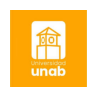

In [11]:
# Reducir el tamaño de la imagen a 1x1 pulgadas para mostrarla con menos resolución
plt.figure(figsize=(1,1))
plt.imshow(img_rgb)
plt.axis('off')  # Ocultar los ejes
plt.show()


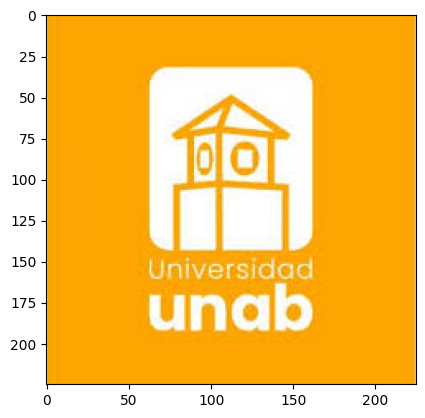

In [12]:
# Mostrar la imagen con los ejes activados
plt.imshow(img_rgb)
plt.axis('on')  # Con los ejes
plt.show()


**Escribir una Imagen**

Para guardar una imagen modificada en disco, utilizamos cv.imwrite():

In [13]:
# Guardar la imagen original como 'output_image.jpg' en el directorio de trabajo actual
cv.imwrite('output_image.jpg', img)
# Ir a la carpeta respectiva y observar el archivo generado: output_image.jpg

True

**Conversión de Formatos de Imagen**

Las imágenes pueden ser convertidas a escala de grises para facilitar ciertos tipos de análisis:

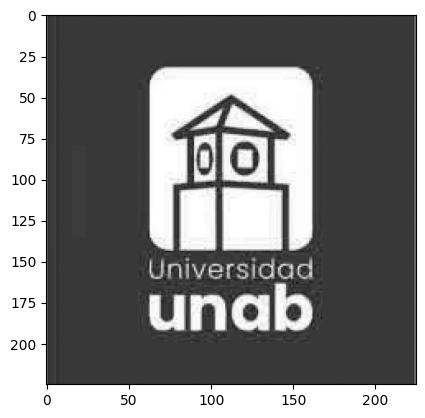

In [14]:
# Convertir la imagen de BGR a escala de grises y mostrarla
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray')
plt.show()



plt.imshow() interpreta el array como una imagen.

Cuando usas cmap='gray', Matplotlib interpreta los valores para mostrar una imagen en escala de grises.

Pero Matplotlib no siempre normaliza la imagen automáticamente. Si el rango de valores no es 0-255 o 0-1, puede ajustar la visualización, haciendo que algunos tonos se vean más “fuertes” o contrastados.

Además, Matplotlib usa su propio mapa de colores y escala de valores para hacer el render, que puede realzar el contraste.

In [15]:
img_gray

array([[196, 169, 172, ..., 173, 173, 196],
       [196, 169, 172, ..., 173, 173, 196],
       [196, 169, 172, ..., 173, 173, 196],
       ...,
       [196, 169, 172, ..., 173, 173, 196],
       [196, 169, 172, ..., 173, 173, 196],
       [196, 169, 172, ..., 173, 173, 196]], dtype=uint8)

Esto puede mostrar la imagen tal cual está en los datos, sin aplicar ningún mapa de colores ni normalización extra.

En OpenCV, la imagen es un array de valores de intensidad, y Jupyter solo muestra el array como una imagen en escala de grises "plana", sin mejorar el contraste o ajustar colores.



Para que Matplotlib muestre la imagen exactamente igual que poner la vriable en el notebook se debe ajustar a valores minimos y maximos.

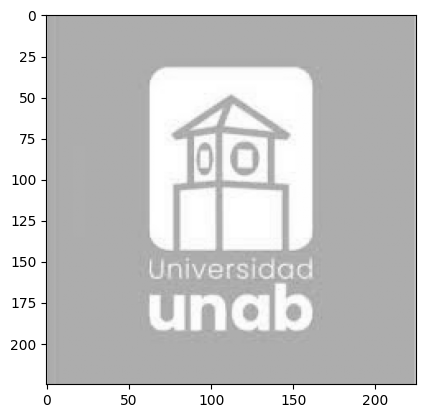

In [16]:
plt.imshow(img_gray, cmap='gray', vmin=0, vmax=255)
plt.show()


In [17]:
# Mostrar las dimensiones de la imagen en escala de grises (alto, ancho)
img_gray.shape

(225, 225)

##Tipos de Imágenes y Conversiones

**Conversión entre tipos de imágenes:**
Si necesitamos cambiar el tipo de una imagen (por ejemplo, de uint8 a float32), podemos usar el método astype() de NumPy:

In [18]:
# Convertir la imagen en escala de grises a tipo float32 y luego volver a uint8
img_float = img_gray.astype(np.float32)  # Convertir a float32
img_back_to_uint8 = img_float.astype(np.uint8)  # Convertir de nuevo a uint8
#img_back_to_uint8
img_back_to_uint8

array([[196, 169, 172, ..., 173, 173, 196],
       [196, 169, 172, ..., 173, 173, 196],
       [196, 169, 172, ..., 173, 173, 196],
       ...,
       [196, 169, 172, ..., 173, 173, 196],
       [196, 169, 172, ..., 173, 173, 196],
       [196, 169, 172, ..., 173, 173, 196]], dtype=uint8)

**Selección de subregiones:**

Puedes seleccionar una parte de la imagen (un subconjunto de píxeles) utilizando índices de la matriz de la imagen. Por ejemplo, si deseas extraer una sección del logo de la imagen

In [19]:
# Mostrar un recorte de la imagen uint8 en el rango de filas 160-200 y columnas 50-170
img_back_to_uint8[160:200, 50:170]


array([[173, 173, 173, ..., 175, 173, 173],
       [173, 173, 173, ..., 177, 173, 173],
       [173, 173, 173, ..., 173, 173, 173],
       ...,
       [173, 173, 173, ..., 173, 173, 173],
       [173, 173, 173, ..., 173, 173, 173],
       [173, 173, 173, ..., 173, 173, 173]], dtype=uint8)

#Escala de Blanco y Negro
Este código convierte una imagen en blanco y negro y luego la muestra utilizando la biblioteca Matplotlib. Primero, la imagen se convierte de su formato de color original (BGR) en Balnco y Negro.

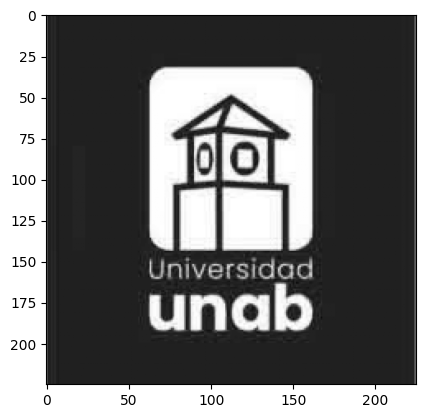

array([[165, 126, 126, ..., 127, 128, 166],
       [165, 126, 126, ..., 127, 128, 166],
       [165, 126, 126, ..., 127, 128, 166],
       ...,
       [165, 126, 126, ..., 127, 128, 166],
       [165, 126, 126, ..., 127, 128, 166],
       [165, 126, 126, ..., 127, 128, 166]], dtype=uint8)

In [20]:
# Convertir la imagen a escala de grise
gray_image = cv.cvtColor(img_rgb, cv.COLOR_BGR2GRAY)
# Mostrar la imagen usando Matplotlib
plt.imshow(gray_image, cmap='gray')
plt.show()
gray_image

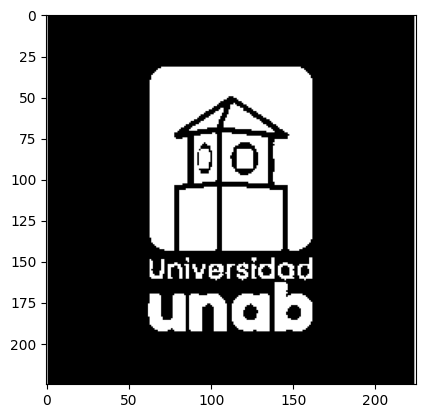

array([[255,   0,   0, ...,   0,   0, 255],
       [255,   0,   0, ...,   0,   0, 255],
       [255,   0,   0, ...,   0,   0, 255],
       ...,
       [255,   0,   0, ...,   0,   0, 255],
       [255,   0,   0, ...,   0,   0, 255],
       [255,   0,   0, ...,   0,   0, 255]], dtype=uint8)

In [21]:
img_rgb

# 2. Convertir la imagen a escala de grises
imagen_gris = cv.cvtColor(img_rgb, cv.COLOR_BGR2GRAY)

# 3. Aplicar un umbral binario para crear una imagen puramente blanco y negro
# El primer valor (127) es el umbral de intensidad, puedes ajustarlo.
# cv2.THRESH_BINARY es el tipo de umbral binario.
ret, imagen_blanco_negro = cv.threshold(imagen_gris, 150, 255, cv.THRESH_BINARY)

# 4. Mostrar la imagen en blanco y negro usando cv2_imshow para Google Colab
plt.imshow(imagen_blanco_negro, cmap="gray")
plt.show()
imagen_blanco_negro

## Redimensionamiento de una imagen a un nuevo tamaño y visualización

Este código redimensiona una imagen a un tamaño específico (100x100 píxeles) utilizando OpenCV, y luego la muestra utilizando Matplotlib. Primero, se definen las dimensiones deseadas de la imagen, y luego se utiliza la función cv2.resize para cambiar el tamaño de la imagen. Finalmente, la imagen redimensionada se muestra en pantalla.

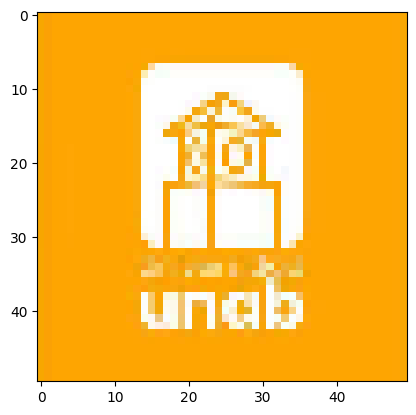

In [22]:
# Definir el nuevo tamaño
new_width, new_height = 50, 50  # Establecer las nuevas dimensiones deseadas (ancho y alto)

# Redimensionar la imagen
image_resized = cv.resize(img_rgb, (new_width, new_height))  # Redimensiona la imagen a las nuevas dimensiones
#image_resized = cv.resize(image_resized, (225,225))

# Mostrar la imagen redimensionada
#plt.figure(figsize=(1,1))
# Mostrar la imagen redimensionada
plt.imshow(image_resized)  # Muestra la imagen redimensionada utilizando Matplotlib
plt.show()  # Muestra la ventana con la imagen redimensionada


In [23]:
image_resized.shape

(50, 50, 3)

## Acceso a un canal de color de una imagen cargada

El código no muestra la imagen en su totalidad, sino que se centra en una porción de la imagen, específicamente los primeros 254 píxeles de las primeras 254 filas, y accede al canal azul.

In [24]:
# Cargar la imagen desde la ruta y mostrar el canal rojo (índice 2) de una sección de 254x254 píxeles
im = plt.imread('/content/logo.jpg')

im[:254, :254, 2]


array([[79,  0,  0, ...,  3,  3, 86],
       [79,  0,  0, ...,  3,  3, 86],
       [79,  0,  0, ...,  3,  3, 86],
       ...,
       [79,  0,  0, ...,  3,  3, 86],
       [79,  0,  0, ...,  3,  3, 86],
       [79,  0,  0, ...,  3,  3, 86]], dtype=uint8)

In [25]:
Capacolor=np.zeros_like(im[:225, :225])
Capacolor[..., 1] = im[:255, :255, 1]
Capacolor[..., 2] = 0
Capacolor[..., 0] = 0
Capacolor

array([[[  0, 192,   0],
        [  0, 169,   0],
        [  0, 166,   0],
        ...,
        [  0, 167,   0],
        [  0, 169,   0],
        [  0, 192,   0]],

       [[  0, 192,   0],
        [  0, 169,   0],
        [  0, 166,   0],
        ...,
        [  0, 167,   0],
        [  0, 169,   0],
        [  0, 192,   0]],

       [[  0, 192,   0],
        [  0, 169,   0],
        [  0, 166,   0],
        ...,
        [  0, 167,   0],
        [  0, 169,   0],
        [  0, 192,   0]],

       ...,

       [[  0, 192,   0],
        [  0, 169,   0],
        [  0, 166,   0],
        ...,
        [  0, 167,   0],
        [  0, 169,   0],
        [  0, 192,   0]],

       [[  0, 192,   0],
        [  0, 169,   0],
        [  0, 166,   0],
        ...,
        [  0, 167,   0],
        [  0, 169,   0],
        [  0, 192,   0]],

       [[  0, 192,   0],
        [  0, 169,   0],
        [  0, 166,   0],
        ...,
        [  0, 167,   0],
        [  0, 169,   0],
        [  0, 192,   0]]

In [ ]:
#solo se ve la primera capa (roja)

Capacolor=np.zeros_like(im[:225, :225])
Capacolor[..., 1] = 0
Capacolor[..., 2] = 0
Capacolor[..., 0] = im[:255, :255, 1] #primera capa (roja) de la imagen
Capacolor

array([[[192,   0,   0],
        [169,   0,   0],
        [166,   0,   0],
        ...,
        [167,   0,   0],
        [169,   0,   0],
        [192,   0,   0]],

       [[192,   0,   0],
        [169,   0,   0],
        [166,   0,   0],
        ...,
        [167,   0,   0],
        [169,   0,   0],
        [192,   0,   0]],

       [[192,   0,   0],
        [169,   0,   0],
        [166,   0,   0],
        ...,
        [167,   0,   0],
        [169,   0,   0],
        [192,   0,   0]],

       ...,

       [[192,   0,   0],
        [169,   0,   0],
        [166,   0,   0],
        ...,
        [167,   0,   0],
        [169,   0,   0],
        [192,   0,   0]],

       [[192,   0,   0],
        [169,   0,   0],
        [166,   0,   0],
        ...,
        [167,   0,   0],
        [169,   0,   0],
        [192,   0,   0]],

       [[192,   0,   0],
        [169,   0,   0],
        [166,   0,   0],
        ...,
        [167,   0,   0],
        [169,   0,   0],
        [192,   0,   0]]

In [26]:
# Extraer un recorte de la imagen desde (0:254, 0:254) tomando solo el canal 1

im[:254,:254,1]

array([[192, 169, 166, ..., 167, 169, 192],
       [192, 169, 166, ..., 167, 169, 192],
       [192, 169, 166, ..., 167, 169, 192],
       ...,
       [192, 169, 166, ..., 167, 169, 192],
       [192, 169, 166, ..., 167, 169, 192],
       [192, 169, 166, ..., 167, 169, 192]], dtype=uint8)

In [27]:
# Definir un color en formato BGR: Azul=255, Verde=0, Rojo=128

im[:254,:254,0]

array([[249, 235, 251, ..., 249, 246, 245],
       [249, 235, 251, ..., 249, 246, 245],
       [249, 235, 251, ..., 249, 246, 245],
       ...,
       [249, 235, 251, ..., 249, 246, 245],
       [249, 235, 251, ..., 249, 246, 245],
       [249, 235, 251, ..., 249, 246, 245]], dtype=uint8)

**Imágenes como arreglos 1D:**

En la forma más simple, una imagen podría representarse como un arreglo unidimensional (1D). Este tipo de representación es muy rara en el contexto de imágenes, pero se puede entender mejor al imaginar que se aplana la imagen en una secuencia lineal de píxeles.

Ejemplo: Si tenemos una imagen muy pequeña de 3 píxeles (blanco, negro y gris), podríamos representarla como un arreglo 1D:

In [30]:
# Vector que representa un color en formato BGR (Azul=255, Verde=0, Rojo=128)
[255, 0, 128] # Blanco, Negro y Gris

[255, 0, 128]

**Imágenes como arreglos 2D (Escala de grises):**

Una imagen en escala de grises se puede representar como un arreglo bidimensional (2D), en donde cada valor de la matriz corresponde a la intensidad de un píxel en la imagen. Este tipo de representación es común cuando la imagen no tiene color, sino solo variaciones de luz.

Ejemplo: Imagina una imagen de 3x3 píxeles en escala de grises:

In [31]:
# Matriz de valores que representan colores o intensidades por fila:
# Fila 1: [255, 0, 128]  → valores altos y bajos (ejemplo de intensidades o color BGR)
# Fila 2: [50, 200, 100] → mezcla de valores medios
# Fila 3: [0, 255, 50]   → incluye mínimo y máximo de intensidad
[[255, 0, 128],     # Fila 1: Blanco, Negro, Gris
 [50, 200, 100],    # Fila 2: Gris oscuro, Rojo, Verde
 [0, 255, 50]]      # Fila 3: Negro, Blanco, Verde


[[255, 0, 128], [50, 200, 100], [0, 255, 50]]

**Imágenes como arreglos 3D (RGB o color):**

Las imágenes a color, como las que ves en una pantalla, se representan comúnmente como arreglos tridimensionales (3D). Aquí, cada píxel no tiene solo un valor de intensidad, sino tres valores,
correspondientes a los colores primarios: **rojo (R), verde (G) y azul (B)**. La representación de una imagen colorida es entonces una matriz 3D, donde:

La primera dimensión es el número de filas (alto de la imagen).

La segunda dimensión es el número de columnas (ancho de la imagen).

La tercera dimensión tiene una longitud de 3, que corresponde a los canales de color (Rojo, Verde y Azul).

Ejemplo: Imagina una imagen de 2x2 píxeles a color, donde cada valor de cada píxel se expresa en términos de RGB. El arreglo 3D correspondiente sería:

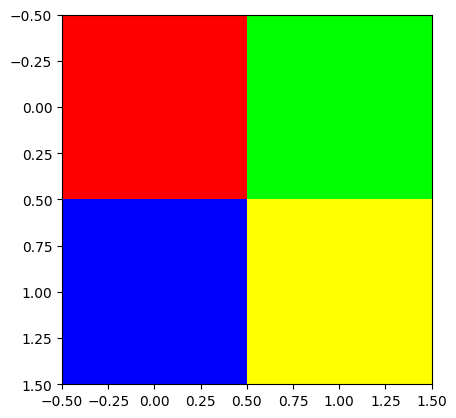

In [32]:
# Matriz 2x2 de colores RGB:
# Fila 1: Rojo, Verde
# Fila 2: Azul, Amarillo
imagen_manual=np.array([
 [[255, 0, 0], [0, 255, 0]],    # Fila 1: Rojo, Verde
 [[0, 0, 255], [255, 255, 0]]   # Fila 2: Azul, Amarillo
])

#Visualizaremos la imagen.
plt.imshow([ [[255, 0, 0], [0, 255, 0]],    # Fila 1: Rojo, Verde
 [[0, 0, 255], [255, 255, 0]]   # Fila 2: Azul, Amarillo
])
plt.show()

In [33]:
imagen_manual.shape

(2, 2, 3)

**1D:** Es una representación plana y poco común para imágenes, adecuada solo en ciertos casos de procesamiento.

**2D:** Es común para imágenes en escala de grises, donde cada píxel tiene solo un valor de intensidad.

**3D:** Es la forma estándar para imágenes a color (RGB), donde cada píxel tiene tres valores representando los canales de color.

##Inspección de las dimensiones de un arreglo multidimensional

Este código crea un arreglo NumPy tridimensional que representa una imagen con dos filas de píxeles, donde cada píxel tiene tres valores (RGB). Luego, el código muestra las dimensiones del arreglo utilizando el atributo .shape de NumPy, que devuelve la forma (tamaño) del arreglo en cada eje.

In [34]:
a = np.array([[[184, 134, 11], [20,90,70],[10,30,0],[90,60,90]],
                [[255, 0, 127], [70,40,50],[40,30,20],[50,50,80]]])

In [35]:
a.shape

(2, 4, 3)

In [36]:
a

array([[[184, 134,  11],
        [ 20,  90,  70],
        [ 10,  30,   0],
        [ 90,  60,  90]],

       [[255,   0, 127],
        [ 70,  40,  50],
        [ 40,  30,  20],
        [ 50,  50,  80]]])

a.ndim : Devuelve el número de dimensiones del array a.

a.shape : Devuelve una tupla con las dimensiones del array a.

a.size : Devuelve el número de elementos del array a.

a.dtype: Devuelve el tipo de datos de los elementos del array a.

In [37]:
a.ndim

3

In [43]:
a.shape

(2, 4, 3)

In [44]:
a.size

24

In [45]:
a.dtype

dtype('int64')

<function matplotlib.pyplot.show(close=None, block=None)>

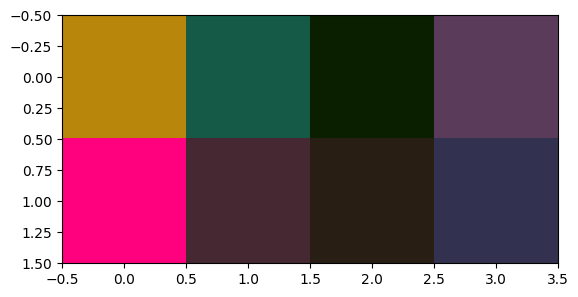

In [46]:
plt.imshow(a)
plt.show

##Concatenación de arreglos 3D en NumPy

Este código crea dos arreglos tridimensionales (a y a2) y luego los concatena a lo largo del primer eje (filas). Esto permite combinar dos bloques de píxeles (representados como matrices 3D) en un único arreglo más grande. La concatenación se realiza utilizando la función np.concatenate(), especificando axis=0 para indicar que la operación debe realizarse a lo largo del primer eje, es decir, apilando los arreglos verticalmente (añadiendo filas).

In [47]:
import numpy as np

# Primer arreglo 3D 'a' (con 2 filas y 4 píxeles por fila, cada uno con 3 valores RGB)
a = np.array([[[10, 40, 70], [20, 90, 70], [10, 30, 0], [90, 60, 90]],
              [[255, 0, 127], [70, 40, 50], [40, 30, 20], [50, 50, 80]]])

# Segundo arreglo 3D 'a2' (también con 2 filas y 4 píxeles por fila, cada uno con 3 valores RGB)
a2 = np.array([[[255, 64, 0], [255, 128, 0], [255, 191, 0], [255, 255, 0]],
               [[42, 87, 131], [120, 169, 206], [64, 255, 0], [0, 255, 0]]])

# Concatenar los dos arreglos a lo largo del eje 0 (filas)
a = np.concatenate((a, a2), axis=0)

# Mostrar la forma del arreglo concatenado (nueva imagen)
print(a.shape)  # Devuelve las dimensiones del arreglo concatenado



(4, 4, 3)


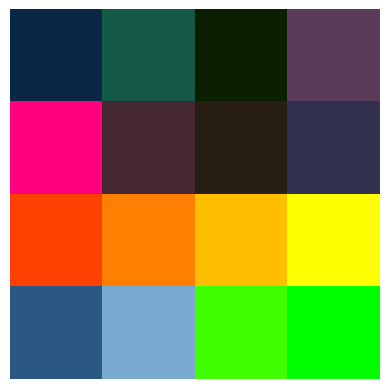

In [48]:
# Mostrar la imagen

plt.imshow(a)
plt.axis('off')  # Desactivar ejes
plt.show()

##Iteración sobre un canal específico de una imagen 3D en NumPy
Este código itera a través de todos los valores del primer canal (rojo) de la imagen a, que se ha representado como un arreglo 3D. Utiliza np.nditer() para recorrer todos los elementos de una sección específica del arreglo (en este caso, la primera capa o canal de color, que corresponde al valor en el índice 0 de cada píxel). La iteración extrae y muestra cada valor del canal rojo de la imagen.

In [49]:
# Iterar sobre el primer canal de la imagen (el canal rojo, índice 0)
for x in np.nditer(a[:,:,0]):
    print(x)  # Imprime cada valor del canal rojo


10
20
10
90
255
70
40
50
255
255
255
255
42
120
64
0


##Aplanar un arreglo 3D a un arreglo 1D en NumPy
Para convertir un arreglo multidimensional (como una imagen representada en 3D) en un arreglo unidimensional (1D), se puede utilizar el método flatten() o la función ravel() de NumPy. Estas funciones "aplanan" el arreglo, es decir, lo convierten en una secuencia lineal de valores.

Esta operación no se visualiza el arreglo plano, pero si es necesario aprenderlo para usarlo en las redes neuronales porque la capa de entrada solo recibe arreglos planos.


In [50]:
# Aplanar el arreglo 3D en un arreglo 1D
flattened_array = a.flatten()  # Usa flatten() para aplanar el arreglo

# Mostrar el arreglo aplanado
print(flattened_array)

[ 10  40  70  20  90  70  10  30   0  90  60  90 255   0 127  70  40  50
  40  30  20  50  50  80 255  64   0 255 128   0 255 191   0 255 255   0
  42  87 131 120 169 206  64 255   0   0 255   0]


##Alternativa con ravel():

ravel() también aplanea un arreglo, pero a diferencia de flatten(), ravel() devuelve una vista del arreglo original cuando es posible, lo que puede ser más eficiente en términos de memoria.
En este caso, el uso de ravel() produciría el mismo resultado que flatten().

In [51]:
flattened_array_ravel = a.ravel()  # Alternativa con ravel()
print(flattened_array_ravel)

[ 10  40  70  20  90  70  10  30   0  90  60  90 255   0 127  70  40  50
  40  30  20  50  50  80 255  64   0 255 128   0 255 191   0 255 255   0
  42  87 131 120 169 206  64 255   0   0 255   0]


##Visualización del primer canal de una imagen (rojo) usando Matplotlib

Este código muestra cómo visualizar solo el primer canal (rojo) de una imagen representada en un arreglo 3D utilizando la biblioteca Matplotlib. La imagen original se encuentra en el arreglo a, y se selecciona el primer canal (a[:,:,0]) para su visualización. Además, se desactivan los ejes para una visualización más limpia de la imagen.

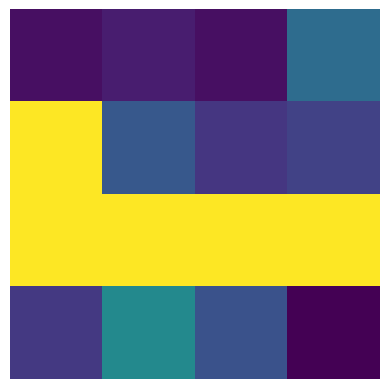

In [52]:
# Mostrar solo el primer canal (rojo) de la imagen
plt.imshow(a[:,:,0])
plt.axis('off')  # Desactivar los ejes para una visualización más limpia
plt.show()  # Mostrar la imagen

[Codigos colores]("https://www.w3schools.com/colors/colors_picker.asp")

#Función auxiliar para mostrar una imagen con Matplotlib en un tamaño ajustado

Este código define una función auxiliar llamada plti, que permite mostrar una imagen de manera que se ajuste a un tamaño proporcional según las dimensiones de la imagen. Esta función la vamos a usar más adelante en los ejercicios.

La altura de la imagen (h) se especifica como un parámetro, y la anchura se calcula de forma proporcional para mantener las proporciones de la imagen.

La función usa Matplotlib para visualizar la imagen y desactivar los ejes.


Esta función plti es un ayudante para trazar una imagen utilizando matplotlib. Aquí está cómo funciona:

Toma una matriz de imagen im como entrada.

h es un parámetro opcional que especifica la altura de la imagen en pulgadas. El valor predeterminado es 8 pulgadas.

Calcula la relación de aspecto de la imagen dividiendo la altura (y) entre la anchura (x) y luego ajusta la anchura (w) en consecuencia para mantener la relación de aspecto original.
Crea una figura con el tamaño ajustado según la relación de aspecto calculada y la altura especificada (h).
Utiliza plt.imshow() para mostrar la imagen im sin interpolación y con cualquier otro argumento adicional especificado en **kwargs.
Finalmente, desactiva los ejes de la imagen utilizando plt.axis('off').
Esta función facilita el trazado de imágenes con matplotlib al manejar automáticamente el tamaño y la relación de aspecto de la imagen para que se muestre correctamente en la figura.

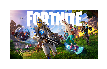

In [53]:
def plti(im, h, **kwargs):
    """
    Función auxiliar para mostrar una imagen con un tamaño proporcional.

    Parameters:
    im (array): La imagen a mostrar.
    h (int or float): La altura deseada de la imagen en pulgadas.
    kwargs: Argumentos adicionales que se pasan a la función imshow.
    """
    # Obtener las dimensiones de la imagen (alto y ancho)
    y = im.shape[0]  # Altura de la imagen
    x = im.shape[1]  # Ancho de la imagen

    # Calcular el ancho proporcional en función de la altura 'h'
    w = (y / x) * h

    # Crear la figura con el tamaño calculado
    plt.figure(figsize=(w, h))

    # Mostrar la imagen sin interpolación (para evitar distorsión)
    plt.imshow(im, interpolation="none", **kwargs)

    # Desactivar los ejes para una visualización más limpia
    plt.axis('off')

    # Mostrar la imagen
    plt.show()

# Llamar a la función plti para mostrar una imagen
plti(im,2) #2 pulgdas


#Usar la libreria de opencv

Ahora usamos la función cv2.imread() de OpenCV para cargar la imagen ubicada en la ruta definida arriba, para luego desplegarla en pantalla usando cv2.imshow().

En Google Colab, es mejor usar cv2_imshow() de OpenCV en lugar de plt.imshow() para mostrar imágenes que se cargan utilizando OpenCV (cv2). Esto se debe a que cv2.imshow() no funciona correctamente en entornos como Google Colab debido a la falta de una interfaz gráfica. Sin embargo, cv2_imshow() está específicamente diseñado para mostrar imágenes en este tipo de entornos.

In [54]:
# Mostramos la imagen usando cv2_imshow
cv2_imshow(img)

# Opcional: esperar a que se cierre la ventana (no necesario en Colab)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
# En Google Colab, es mejor usar cv2_imshow() en lugar de

NameError: name 'cv2_imshow' is not defined

##Recorte y visualización de una sección de una imagen en Google Colab

Este código descarga una imagen de Internet, la carga en un arreglo usando plt.imread(), y luego recorta una sección específica de la imagen. Finalmente, se muestra la sección recortada de la imagen utilizando plt.imshow().

Vamos a recortar esta foto de Fornite. Esta es la imagen original.

![image](https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/fortnite-og-social-1920x1080-a5adda66fab9.jpg)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  320k  100  320k    0     0  5374k      0 --:--:-- --:--:-- --:--:-- 5438k
(1080, 1920, 3)


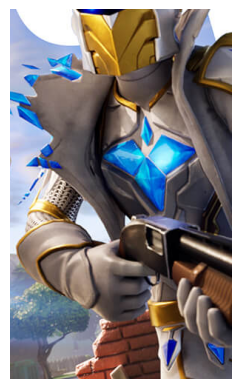

In [55]:

# Descargar la imagen de una URL
!curl -O "https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/fortnite-og-social-1920x1080-a5adda66fab9.jpg"

# Cargar la imagen usando Matplotlib
im = plt.imread("/content/fortnite-og-social-1920x1080-a5adda66fab9.jpg")

# Imprimir las dimensiones de la imagen (alto, ancho, canales)
print(im.shape)

# Recortar una sección de la imagen (de las filas 300 a 800 y de las columnas 500 a 800)
im3 = im[300:800, 500:800, :]

# Mostrar la imagen recortada
plt.imshow(im3)
plt.axis('off')  # Desactivar los ejes para una visualización más limpia
plt.show()


##Extracción de un canal específico de una imagen recortada

Este código recorta una sección específica de la imagen y luego extrae solo el primer canal (rojo, correspondiente al índice 0 en una imagen en formato RGB) de la sección recortada.

In [56]:
# Recortar una sección de la imagen (de las filas 200 a 600 y de las columnas 500 a 800)
# Luego, extraer solo el canal rojo (el primer canal, índice 0)
im0 = im[200:600, 500:800, 0]

# Mostrar el resultado de la sección recortada con solo el canal rojo
print(im0)
im0

[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [224 225 226 ...  35  52  73]
 [225 225 226 ...  31  44  65]
 [227 227 227 ...  29  39  60]]


array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [224, 225, 226, ...,  35,  52,  73],
       [225, 225, 226, ...,  31,  44,  65],
       [227, 227, 227, ...,  29,  39,  60]], dtype=uint8)

##Extracción y visualización de solo el canal verde de una imagen

Este código extrae solo el canal verde de una sección recortada de la imagen y luego crea una nueva imagen en la que solo el canal verde tiene información de color, mientras que los canales rojo y azul se configuran a 0. Finalmente, se muestra la nueva imagen resultante.

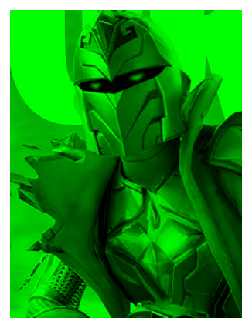

In [57]:
# Recortar una sección de la imagen original (de las filas 200 a 600 y de las columnas 500 a 800)
# Crear una imagen vacía de la misma forma
im0_color = np.zeros_like(im[200:600, 500:800])  # Crear un arreglo vacío con la misma forma

# Asignar el canal rojo a 0
im0_color[..., 0] = 0

# Establecer el canal verde con los valores del canal verde de la imagen original
im0_color[..., 1] = im[200:600, 500:800, 1]

# Asignar el canal azul a 0
im0_color[..., 2] = 0

# Mostrar la imagen resultante con solo el canal verde
plti(im0_color,4)


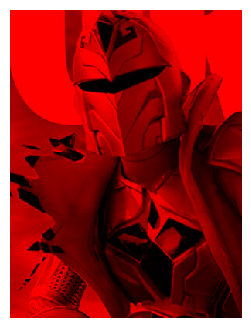

In [58]:
# Recortar una sección de la imagen original (de las filas 200 a 600 y de las columnas 500 a 800)
# Crear una imagen vacía de la misma forma
im0_color = np.zeros_like(im[200:600, 500:800])  # Crear un arreglo vacío con la misma forma

#Establecer el canal rojo con los valores del canal rojo de la imagen original
im0_color[..., 0] = im[200:600, 500:800, 0]


# Asignar el canal verde a 0
im0_color[..., 1] = 0

# Asignar el canal azul a 0
im0_color[..., 2] = 0

# Mostrar la imagen resultante con solo el canal verde
plti(im0_color,4)


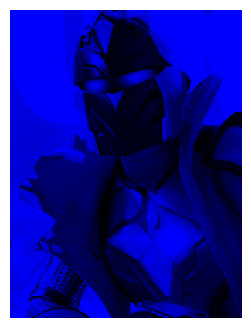

In [59]:
# Recortar una sección de la imagen original (de las filas 200 a 600 y de las columnas 500 a 800)
# Crear una imagen vacía de la misma forma
im0_color = np.zeros_like(im[200:600, 500:800])  # Crear un arreglo vacío con la misma forma

# Asignar el canal rojo a 0
im0_color[..., 0] = 0

# Asignar el canal verde a 0
im0_color[..., 1] = 0

#Establecer el canal verde con los valores del canal verde de la imagen original

im0_color[..., 2] = im[200:600, 500:800, 2]

# Mostrar la imagen resultante con solo el canal verde
plti(im0_color,4)


#Visualizar cada capa o canal de color individualmente

Este código extrae y muestra los canales individuales de una imagen cargada (im), que contiene tres canales de color: rojo, verde y azul. Utiliza Matplotlib para mostrar cada canal en una figura separada en escala de grises. Los tres canales se visualizan en una única fila de subgráficos.



La razón por la que los canales rojo, verde y azul se muestran en blanco y negro (escala de grises) es porque se están visualizando por separado en escala de grises en lugar de mostrarse como imágenes a color.

**Explicación detallada:**

Cada imagen en formato RGB tiene tres canales:

Canal Rojo (R)

Canal Verde (G)

Canal Azul (B)


Cuando haces un recorte de los canales individuales como im[:, :, 0], im[:, :, 1] y im[:, :, 2], lo que estás obteniendo son matrices 2D (de forma alto x ancho) que contienen solo los valores de intensidad de cada canal, sin ninguna mezcla de color. Estos valores son simplemente números que representan la intensidad de ese canal en cada píxel.


Cuando usas plt.imshow(..., cmap='gray'), Matplotlib interpreta esas intensidades de canal y las muestra como imágenes en escala de grises. En este caso, cada imagen está representando una intensidad de color sin ningún color adicional, por lo que el resultado es una imagen blanco y negro donde los valores más altos corresponden a tonos más claros y los valores más bajos a tonos más oscuros.

In [60]:
# Supongamos que 'im' es la imagen cargada
red_channel = im[:, :, 0]    # Canal rojo
green_channel = im[:, :, 1]  # Canal verde
blue_channel = im[:, :, 2]   # Canal azul


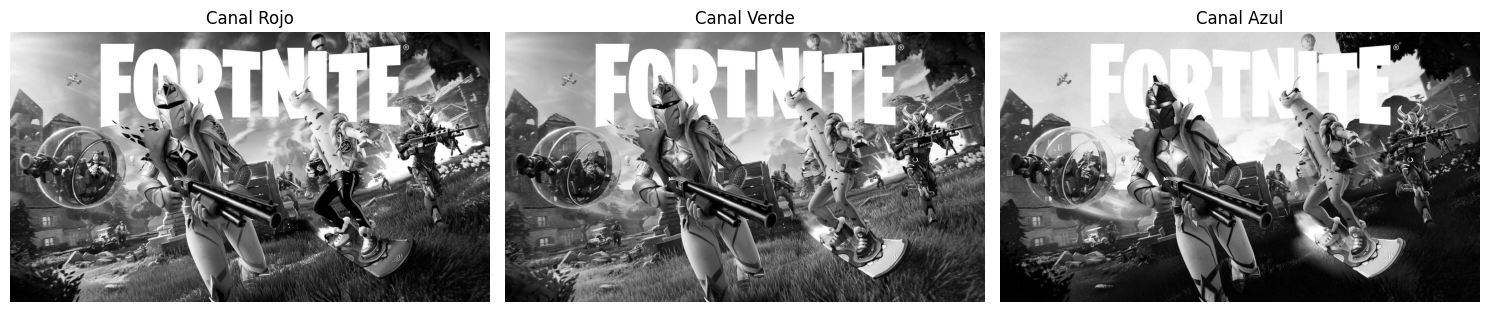

In [61]:
# Visualizar los canales
plt.figure(figsize=(15, 5))  # Definir el tamaño de la figura

# Canal Rojo
plt.subplot(1, 3, 1)  # Crear el primer subgráfico (1 fila, 3 columnas, 1er subgráfico)
plt.imshow(red_channel, cmap='gray')  # Mostrar el canal rojo en escala de grises
plt.title('Canal Rojo')  # Título del subgráfico
plt.axis('off')  # Desactivar los ejes para una visualización más limpia

# Canal Verde
plt.subplot(1, 3, 2)  # Crear el segundo subgráfico
plt.imshow(green_channel, cmap='gray')  # Mostrar el canal verde en escala de grises
plt.title('Canal Verde')  # Título del subgráfico
plt.axis('off')  # Desactivar los ejes

# Canal Azul
plt.subplot(1, 3, 3)  # Crear el tercer subgráfico
plt.imshow(blue_channel, cmap='gray')  # Mostrar el canal azul en escala de grises
plt.title('Canal Azul')  # Título del subgráfico
plt.axis('off')  # Desactivar los ejes

plt.tight_layout()  # Ajustar el espacio entre los subgráficos para que no se solapen
plt.show()  # Mostrar la figura con los tres canales

##Visualización de los canales individuales de color con su respectivo color en la imagen

Este código carga una imagen, extrae una sección de ella y luego crea imágenes para cada uno de los canales de color (rojo, verde y azul) de esa región. Para cada canal, se construye una nueva imagen en la que solo el canal seleccionado tiene valores, mientras que los otros dos canales están apagados (en 0). Luego, se muestran las tres imágenes con sus colores respectivos.

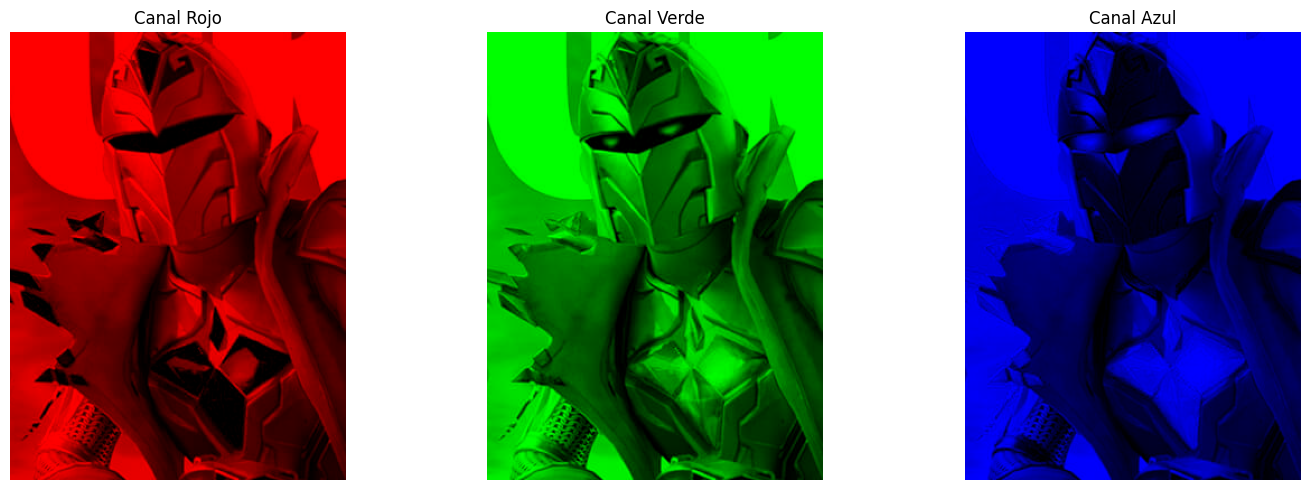

In [62]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen
im = cv2.imread('/content/fortnite-og-social-1920x1080-a5adda66fab9.jpg')
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)  # Convertir de BGR a RGB

# Extraer una región de la imagen (de las filas 200 a 600 y de las columnas 500 a 800)
region = im[200:600, 500:800]

# Función para crear imágenes de un solo canal
def create_color_image(channel, color_index):
    color_image = np.zeros_like(region)  # Crear un arreglo vacío con la misma forma
    color_image[..., color_index] = channel  # Asignar el canal correspondiente
    return color_image

# Crear imágenes para cada canal (rojo, verde, azul)
red_image = create_color_image(region[:, :, 0], 0)    # Imagen solo con el canal rojo
green_image = create_color_image(region[:, :, 1], 1)  # Imagen solo con el canal verde
blue_image = create_color_image(region[:, :, 2], 2)   # Imagen solo con el canal azul

# Mostrar las imágenes en color
plt.figure(figsize=(15, 5))

# Mostrar el canal rojo
plt.subplot(1, 3, 1)
plt.imshow(red_image)
plt.title('Canal Rojo')
plt.axis('off')

# Mostrar el canal verde
plt.subplot(1, 3, 2)
plt.imshow(green_image)
plt.title('Canal Verde')
plt.axis('off')

# Mostrar el canal azul
plt.subplot(1, 3, 3)
plt.imshow(blue_image)
plt.title('Canal Azul')
plt.axis('off')

plt.tight_layout()  # Ajustar el espacio entre los subgráficos
plt.show()


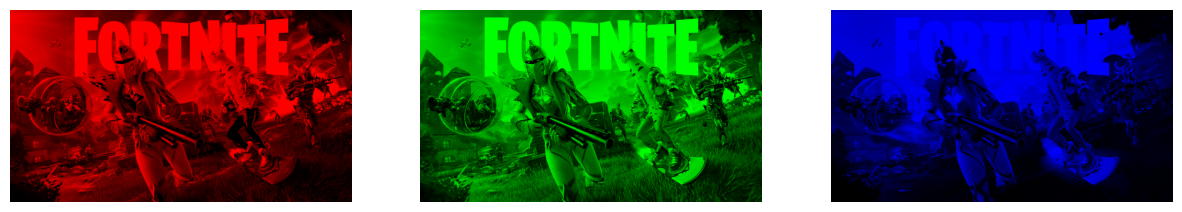

In [63]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

for c, ax in zip(range(3), axs):
    tmp_im = np.zeros(im.shape, dtype="uint8")
    tmp_im[:,:,c] = im[:,:,c]
    ax.imshow(tmp_im)
    ax.set_axis_off()

##Visualización de canales individuales en una imagen utilizando subgráficos

Este código utiliza subgráficos para mostrar los tres canales de color (rojo, verde y azul) de una imagen de forma individual. Crea una nueva imagen para cada canal, donde solo se conserva el canal correspondiente y los otros dos canales se establecen a cero. Luego, visualiza cada una de estas imágenes en subgráficos organizados en una sola fila.

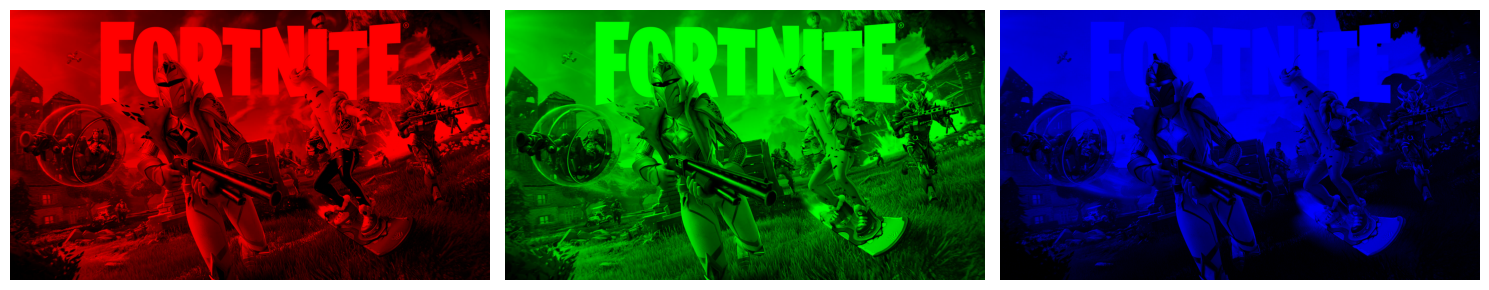

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Supongamos que 'im' es la imagen cargada previamente

# Crear los subgráficos para mostrar los tres canales
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))  # Crear una figura con 1 fila y 3 columnas de subgráficos

# Iterar sobre los 3 canales (rojo, verde y azul)
for c, ax in zip(range(3), axs):
    tmp_im = np.zeros(im.shape, dtype="uint8")  # Crear una imagen vacía del mismo tamaño que 'im'
    tmp_im[:,:,c] = im[:,:,c]  # Asignar solo el canal 'c' a la imagen temporal (rojo, verde o azul)

    ax.imshow(tmp_im)  # Mostrar la imagen con el canal 'c'
    ax.set_axis_off()  # Desactivar los ejes para una visualización más limpia

plt.tight_layout()  # Ajustar el espacio entre los subgráficos
plt.show()  # Mostrar la figura completa



Cuando se utiliza imshow de matplotlib [imshow](http://matplotlib.org/api/axes_api.html#matplotlib.axes.Axes.imshow)  para mostrar imágenes, es importante tener en cuenta qué tipo de datos se está utilizando, ya que el mapeo de colores depende del tipo de datos: si se utiliza un tipo float, los valores se mapean al rango 0-1, por lo que necesitamos convertir a tipo "uint8" para obtener el comportamiento esperado. Se puede encontrar una buena discusión sobre este tema aquí.[here](http://stackoverflow.com/questions/24739769/matplotlib-imshow-plots-different-if-using-colormap-or-rgb-array).




## Transformaciones de Color: Normalización, rotación 3D y desnormalización de una imagen
Representando el color de esta manera, podemos pensar en cada píxel como un punto en un espacio tridimensional. Al considerar el color de esta forma, podemos aplicar diversas transformaciones al "punto" de color. Un ejemplo interesante de estas es "rotar" el color.

Hay algunas sutilezas: los colores legales existen oficialmente como puntos enteros en un cubo tridimensional con lados de longitud 255. Es posible que una rotación pueda empujar un punto fuera de este cubo. Para solucionar esto, aplico una transformación sigmoide a los datos, un mapeo del rango 0-1 a la línea real completa. Después de aplicar esta transformación, aplicamos la matriz de rotación y luego transformamos de nuevo al espacio de color.

La matriz de rotación se aplica píxel por píxel a la imagen utilizando la función de notación de Einstein de numpy, que no había utilizado antes, pero hace que la operación sea concisa.

Este código realiza una serie de transformaciones sobre una imagen: normaliza los valores de los píxeles de la imagen, aplica una rotación 3D sobre ella y luego desnormaliza la imagen transformada. La rotación se realiza alrededor del eje X en un espacio tridimensional, utilizando una matriz de rotación. La imagen es visualizada después de la desnormalización.

## Funciones de normalización y desnormalización:

### `do_normalise(im)`
Esta función normaliza la imagen a un rango diferente utilizando la fórmula:

$$
f(x) = -\log\left( \frac{1}{\left( \frac{1 + \text{imagen}}{257} \right) - 1} \right)
$$

Lo que hace es transformar los valores de los píxeles en un espacio logarítmico para cambiar su distribución.

### `undo_normalise(im)`
Esta función desnormaliza la imagen, llevando los valores de vuelta a su rango original utilizando la fórmula inversa:

$$
f^{-1}(x) = \left( 1 + \frac{1}{e^{-x} + 1} \right) \times 257
$$

Esta fórmula revierte la transformación logarítmica aplicada por la función `do_normalise`.

---

## Función de matriz de rotación 3D:

### `rotation_matrix(theta)`
Esta función genera una matriz de rotación en 3D alrededor del eje X con un ángulo $\theta$. Se utiliza la fórmula estándar para la rotación de un vector en 3D en torno al eje X:

$$
R = \begin{bmatrix}
1 & 0 & 0 \\
0 & \cos(\theta) & -\sin(\theta) \\
0 & \sin(\theta) & \cos(\theta)
\end{bmatrix}
$$

La matriz generada se usará para rotar los valores de los píxeles en 3D.

---

## Transformaciones y visualización:

1. **Normalización**:  
   `im_normed = do_normalise(im)` normaliza la imagen original.

2. **Rotación 3D**:  
   `im_rotated = np.einsum("ijk,lk->ijl", im_normed, rotation_matrix(np.pi))` aplica la rotación 3D a los píxeles de la imagen normalizada. `np.einsum` realiza una multiplicación matricial eficiente.

3. **Desnormalización**:  
   `im2 = undo_normalise(im_rotated)` desnormaliza la imagen rotada para restaurarla a su espacio de píxeles original.

4. **Visualización**:  
   `plti(im2)` usa la función `plti` para mostrar la imagen resultante después de la desnormalización.


Imagen Original


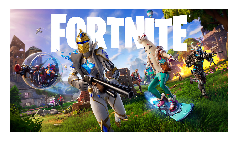

Imagen Normalizada


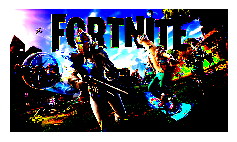

Imagen Rotada


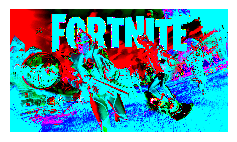

Imagen Desnormalizada


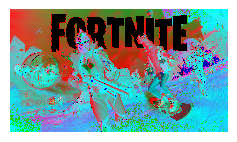

In [65]:

def do_normalise(im):
    epsilon = 1e-8  # Valor pequeño para evitar divisiones por cero
    return -np.log(1 / ((1 + im) / 257 + epsilon) - 1)

def undo_normalise(im):
    """
    Desnormaliza la imagen utilizando la fórmula inversa de la normalización.
    """
    return (1 + 1 / (np.exp(-im) + 1) * 257).astype("uint8")

def rotation_matrix(theta):
    """
    Genera una matriz de rotación 3D alrededor del eje X por un ángulo 'theta'.
    """
    return np.c_[
        [1, 0, 0],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta), np.cos(theta)]
    ]

# Aplicar normalización a la imagen
im_normed = do_normalise(im)

# Rotar la imagen en 3D usando la matriz de rotación alrededor del eje X
im_rotated = np.einsum("ijk,lk->ijl", im_normed, rotation_matrix(np.pi))

# Desnormalizar la imagen después de la rotación
im2 = undo_normalise(im_rotated)

print('Imagen Original')


plti(im,5)

print('Imagen Normalizada')

plti(np.clip(im_normed, 0, 1),5)

print('Imagen Rotada')
plti(np.clip(im_rotated, 0, 1) ,5)

# Visualizar la imagen resultante después de la desnormalización
print('Imagen Desnormalizada')
plti(im2,5)


##Rotación contínua de colores

El siguiente código utiliza FuncAnimation de Matplotlib para crear una animación que rota una imagen en 3D mediante la rotación de sus canales de color.


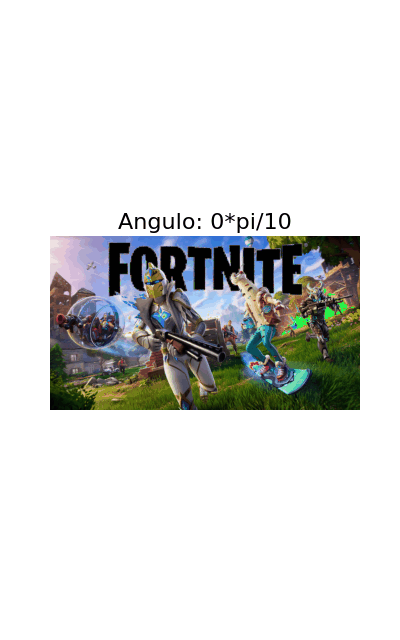

In [66]:
from matplotlib.animation import FuncAnimation
import numpy as np
import matplotlib.pyplot as plt

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(5,8))

# Función de actualización para la animación
def update(i):
    # Normalizar la imagen
    im_normed = do_normalise(im)

    # Rotación de la imagen
    im_rotated = np.einsum("ijk,lk->ijl", im_normed, rotation_matrix(i * np.pi/10))

    # Desnormalizar la imagen
    im2 = undo_normalise(im_rotated)

    # Asegurarse de que la imagen esté en un rango adecuado para mostrarla
    im2 = np.clip(im2, 0, 255).astype(np.uint8)  # Limitar entre 0 y 255

    # Mostrar la imagen en el eje
    ax.imshow(im2)
    ax.set_title("Angulo: {}*pi/10".format(i), fontsize=20)
    ax.set_axis_off()

# Crear la animación
anim = FuncAnimation(fig, update, frames=np.arange(0, 20), interval=50)

# Guardar la animación como un archivo GIF
anim.save('colour_rotation.gif', dpi=80, writer='imagemagick')

# Cerrar la figura después de guardar la animación
plt.close()

# Mostrar el GIF en el cuaderno de Colab
from IPython.display import Image
Image(filename="colour_rotation.gif")


# A Escala de grises

En el tema del color, también podemos transformar la imagen a escala de grises de manera sencilla. Hay varias formas de hacerlo, pero una forma directa es tomar la media ponderada del valor RGB de la imagen original:

Método de Conversión a Escala de Grises


Una forma común de convertir una imagen a escala de grises es usar una fórmula que considera la sensibilidad del ojo humano a los diferentes colores.

Una fórmula común es:

Gris=0.2989×𝑅+0.5870×𝐺+0.1140×𝐵


Esto refleja que el ojo humano es más sensible al verde, seguido del rojo y menos al azul.


# Conversión de Imagen a Escala de Grises y Visualización

Este código realiza la conversión de una imagen a escala de grises usando la fórmula estándar de luminosidad ponderada. La imagen se carga desde una ruta especificada, se convierte a escala de grises y luego se muestra usando `Matplotlib`.

## Descripción

1.. **Conversión a Escala de Grises**: Se utiliza la fórmula ponderada para convertir los valores de color RGB en valores de escala de grises.

2. **Mostrar la Imagen**: La imagen resultante se muestra utilizando `Matplotlib`, sin los ejes y con un título que describe la transformación.

La fórmula utilizada para la conversión es:


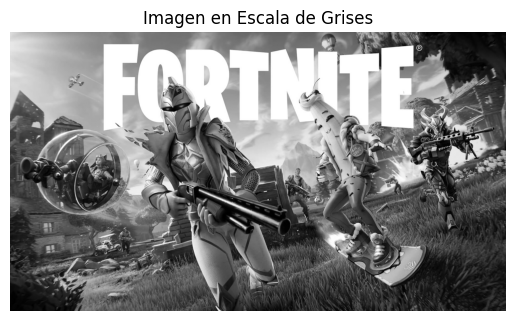

In [67]:
# Convertir la imagen a escala de grises utilizando la fórmula de luminosidad
# Se utiliza una ponderación estándar para cada canal de color:
# 0.2989 * Rojo + 0.5870 * Verde + 0.1140 * Azul
grey_image = 0.2989 * im[:, :, 0] + 0.5870 * im[:, :, 1] + 0.1140 * im[:, :, 2]

# Asegurarse de que los valores de la imagen estén en el rango adecuado de 0 a 255 (uint8)
grey_image = grey_image.astype(np.uint8)  # Convertir a uint8 para representación correcta de la imagen

# Mostrar la imagen en escala de grises utilizando Matplotlib
# Se utiliza el mapa de colores 'gray' para representar la imagen en escala de grises
plt.imshow(grey_image, cmap='gray')

# Desactivar los ejes para que no se muestren en la visualización
plt.axis('off')  # Desactivar ejes

# Título que aparecerá en la imagen mostrada
plt.title('Imagen en Escala de Grises')  # Agregar un título a la imagen

# Mostrar la imagen
plt.show()  # Mostrar la imagen en la pantalla


# Convolución
Otra de las operaciones básicas que puedes aplicar a una imagen es la convolución.

## Definición de Convolución

La convolución es un operador matemático que combina dos funciones para producir una tercera función.

En el contexto de imágenes, se utiliza para aplicar filtros o kernels a la imagen original. E

Este proceso permite realizar diversas tareas, como suavizado, detección de bordes y realce de características.

$C(x,y) = \int dx'dy' I(x + x',y + y') W(x',y')$


Donde
* 𝐶 es la imagen convolucionada,
* 𝐼 es la imagen original
* 𝑊 es una función de ventana.

Esencialmente, estamos reemplazando cada píxel con una suma ponderada de píxeles cercanos.

### Reducción de la Imagen


Debido a que las convoluciones pueden ser costosas en términos computacionales, comenzamos por reducir el tamaño de la imagen.



#Kernel
Un kernel (o filtro) es una matriz pequeña que se mueve a través de la imagen. El tamaño más común de un kernel es 3x3, pero también existen kernels de tamaños mayores como 5x5 o 7x7, dependiendo de la aplicación.

El kernel se coloca sobre la imagen y, para cada píxel, realiza una multiplicación elemento a elemento con la vecindad de píxeles de la imagen, seguida de una suma de esos productos.

En la  siguiente imagen observamos un kernel de 3x3, que toma el subarreglo de 3x3 de la imagen original y hacer una operación de multiplicación y suma y el resultado lo pone en la imagen de salida. Como veremos más adelante aparecentemente pierde resolución, pero depede del kernel resaltamos contornos, formas ,etc.

![imagen](https://github.com/adiacla/bigdata/blob/master/kernel.png?raw=true)


Es esta imagen se aprecia tambien con detalle dicha transformación

![imagen](https://github.com/adiacla/bigdata/blob/master/kernel2.png?raw=true)




##Tipos de Kernel

Los kernels se usan para diferentes tareas en procesamiento de imágenes. Algunos de los más comunes son:

**Filtro de suavizado (Blur):** Suaviza la imagen al promediar los píxeles vecinos.

Ejemplo de un kernel de suavizado 3x3:

$$
\begin{bmatrix}
\frac{1}{9} & \frac{1}{9} & \frac{1}{9} \\
\frac{1}{9} & \frac{1}{9} & \frac{1}{9} \\
\frac{1}{9} & \frac{1}{9} & \frac{1}{9}
\end{bmatrix}
$$



Filtro de detección de bordes (Edge Detection): Detecta los bordes de los objetos dentro de una imagen. Un ejemplo es el filtro de Sobel.

Kernel de detección de bordes en la dirección horizontal (Sobel):

$$
\begin{bmatrix}
-1 &  0 &  1 \\
-2 &  0 &  2 \\
-1 &  0 &  1
\end{bmatrix}
$$

Filtro de nitidez (Sharpening): Aumenta el contraste de la imagen, destacando las áreas de alta frecuencia.

Ejemplo de un kernel de nitidez:

$$
\begin{bmatrix}
 0 & -1 &  0 \\
-1 &  5 & -1 \\
 0 & -1 &  0
\end{bmatrix}
$$



Algunos otros kernel y sus aplicaciones las puede observar en la siguiente imagen.

![imagen](https://github.com/adiacla/bigdata/blob/master/kernel3.png?raw=true)

##Reducción de Tamaño de la Imagen y Aplicación de un Filtro de Desenfoque (Convolución)

Este código realiza dos operaciones en una imagen:

Reducción de Tamaño: Reduce el tamaño de la imagen a la mitad, lo que puede ser útil cuando se necesita reducir la carga computacional o cuando se trabaja con imágenes de gran tamaño.


Convolución con un Filtro de Desenfoque: Aplica un filtro de desenfoque utilizando una matriz kernel de promedio. Esto suaviza la imagen, lo que puede ser útil para eliminar detalles finos y reducir el ruido.

Kernel de Promedio: El filtro utilizado en este caso es un filtro de promedio (o desenfoque), que es una matriz de tamaño  5×5 donde todos los valores son 1. El valor 25 es el tamaño total de la matriz 5×5.

Esto asegura que al aplicar este filtro, cada píxel en la imagen es reemplazado por el promedio de sus píxeles vecinos en una vecindad de 5×5.

Esta operación suaviza la imagen, ayudando a reducir detalles y ruido.

In [61]:
img_rgb

In [62]:
# Reducir el tamaño de la imagen (por ejemplo, la mitad)

reduced_image = cv.resize(im, (img_rgb.shape[1] // 2, img_rgb.shape[0] // 2))


In [63]:
reduced_image

In [64]:
reduced_image.shape

In [65]:
np.ones((5, 5), np.float32)

In [66]:

# Aplicar una convolución simple (por ejemplo, un filtro de desenfoque)

#Crear el filtro

kernel = np.ones((5, 5), np.float32) / 15 # Kernel de promedio
kernel

Este código realiza una convolución en una imagen que previamente ha sido reducida de tamaño, utilizando un filtro de desenfoque. A continuación, se muestran tanto la imagen original reducida como la imagen resultante de la convolución. Se utiliza la función cv2.filter2D() para aplicar el filtro a la imagen, que en este caso es un filtro de promedio o desenfoque.

Finalmente, se visualizan ambas imágenes (original reducida y convolucionada) para comparar el efecto del filtro.

In [67]:
# Aplicar la convolución con el filtro definido (filtro de desenfoque)
# La función cv2.filter2D toma la imagen y el kernel para aplicar la operación de convolución.
# El valor -1 en el segundo parámetro indica que la imagen de salida tendrá el mismo tipo de datos que la imagen de entrada.
convoluted_image = cv2.filter2D(reduced_image, -1, kernel)

# Mostrar la imagen original reducida y la imagen convolucionada
# Crear una figura con dos subgráficas (una para cada imagen)
plt.figure(figsize=(5, 5))

# Subgráfica 1: Imagen Reducida
plt.subplot(1, 2, 1)
plt.imshow(reduced_image)
plt.title('Imagen Reducida')  # Título de la primera imagen
plt.axis('off')  # Desactivar los ejes para mejor visualización

# Subgráfica 2: Imagen Convolucionada (con el filtro de desenfoque)
plt.subplot(1, 2, 2)
plt.imshow(convoluted_image)
plt.title('Imagen Convolucionada')  # Título de la imagen resultante
plt.axis('off')  # Desactivar los ejes para mejor visualización

# Ajustar el espaciado entre las subgráficas
plt.tight_layout()

# Mostrar la figura con ambas imágenes
plt.show()


In [68]:
convoluted_image

##Reducción de Tamaño de la Imagen Usando scipy.ndimage.zoom

Este código utiliza la función zoom de Scipy para reducir el tamaño de la imagen a un 20% de su tamaño original. La función zoom permite realizar un cambio de tamaño de la imagen de manera eficiente, escalando la imagen en los tres canales de color (rojo, verde y azul) de acuerdo a los factores dados.


In [69]:
from scipy.ndimage import zoom

# Reducir la imagen a un 20% de su tamaño original
# La función zoom recibe tres parámetros: la imagen original, un factor de escala para cada dimensión.
# El primer valor (0.2) escala las dimensiones (alto y ancho) al 20% de su tamaño original.
# El segundo valor (0.2) también escala la altura y la anchura.
# El valor 1 indica que no se cambia el número de canales de color (rojo, verde, azul).
im_small = zoom(im, (0.2, 0.2, 1))


Este código visualiza tanto la imagen original como la imagen reducida (al 20% de su tamaño original) para comparar cómo cambia la resolución después de aplicar la reducción de tamaño con la función zoom de Scipy. Se utilizan subgráficas en Matplotlib para mostrar ambas imágenes lado a lado, lo que permite una comparación visual directa de las dos versiones de la imagen.

In [70]:
# Mostrar la imagen original y la imagen reducida
# Crear una figura con dos subgráficas (una para cada imagen)
plt.figure(figsize=(10, 5))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(im)
plt.title('Imagen Original')  # Título de la primera imagen
plt.axis('on')  # Desactivar los ejes para mejor visualización

# Imagen reducida
plt.subplot(1, 2, 2)
plt.imshow(im_small)
plt.title('Imagen Reducida (20%)')  # Título de la imagen reducida
plt.axis('on')  # Desactivar los ejes para mejor visualización

# Ajustar el espaciado entre las subgráficas para evitar solapamientos
plt.tight_layout()

# Mostrar la figura con ambas imágenes
plt.show()


Las imagenes anteriores aparentemente se ven del mismo tamaño.
En Google Colab, cuando visualizas imágenes usando matplotlib o cv2, es posible que el entorno ajuste automáticamente el tamaño de las imágenes para adaptarse al área de visualización disponible. Esto puede hacer que las imágenes se vean del mismo tamaño, incluso si en realidad tienen diferentes dimensiones.

#Ver tamaños reales


In [71]:
# Calcular el tamaño de la figura basado en las dimensiones de la imagen
# (para mantener la proporción original de la imagen)
fig_width = im.shape[1] / 100  # 100 píxeles por pulgada
fig_height = im.shape[0] / 100  # 100 píxeles por pulgada

# Crear la figura con el tamaño ajustado
plt.figure(figsize=(fig_width, fig_height))

# Mostrar la imagen original
plt.imshow(im)
plt.title('Imagen Original')
plt.axis('off')  # Desactivar los ejes
plt.show()

# Crear la figura para la imagen reducida
fig_width_small = im_small.shape[1] / 100
fig_height_small = im_small.shape[0] / 100
plt.figure(figsize=(fig_width_small, fig_height_small))

# Mostrar la imagen reducida
plt.imshow(im_small)
plt.title('Imagen Reducida (20%)')
plt.axis('off')  # Desactivar los ejes
plt.show()

##Visualización de Imagen Original y Reducida con Ajuste de Proporciones

Este código carga una imagen, la reduce al 20% de su tamaño original usando scipy.ndimage.zoom, y luego visualiza ambas imágenes (la original y la reducida) en una misma figura. Para asegurarse de que la imagen reducida mantenga sus proporciones correctas, se ajusta el aspecto de la subgráfica correspondiente, utilizando la relación de las dimensiones de la imagen reducida.

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

# Cargar la imagen (asegúrate de que la variable `im` ya esté definida)
# im = cv2.imread('ruta_a_la_imagen.jpg')  # Ejemplo de carga

# Reducir la imagen a un 20% de su tamaño original
im_small = zoom(im, (0.2, 0.2, 1))  # Reducimos el tamaño de la imagen al 20% en alto y ancho

# Mostrar la imagen original y la imagen reducida
plt.figure(figsize=(12, 6))  # Ajustamos el tamaño de la figura para que ambas imágenes quepan cómodamente

# Imagen original
plt.subplot(1, 2, 1)  # Configuramos la primera subgráfica
plt.imshow(im)  # Mostramos la imagen original
plt.title('Imagen Original')  # Título de la imagen original
plt.axis('off')  # Desactivamos los ejes para mejorar la visualización

# Imagen reducida
plt.subplot(1, 2, 2)  # Configuramos la segunda subgráfica
plt.imshow(im_small)  # Mostramos la imagen reducida
plt.title('Imagen Reducida (20%)')  # Título de la imagen reducida
plt.axis('off')  # Desactivamos los ejes para mejorar la visualización

# Ajustar el tamaño de la figura basado en las dimensiones de la imagen reducida
# Establecemos la relación de aspecto de la imagen reducida
plt.subplot(1, 2, 2).set_aspect(im_small.shape[0] / im_small.shape[1])

# Ajustar el espaciado entre subgráficas para evitar solapamientos
plt.tight_layout()

# Mostrar la figura con las imágenes
plt.show()


#Aplicación de Filtro Uniforme (Desenfoque) en una Imagen Reducida


Este código toma una imagen, la reduce al 20% de su tamaño original utilizando la función zoom de scipy.ndimage, y luego aplica un filtro uniforme (desenfoque) usando uniform_filter. Finalmente, se visualizan tanto la imagen reducida como la imagen desenfocada en una figura con dos subgráficas.


##Ventana Uniforme
Una ventana uniforme (o kernel de promedio) es un filtro que asigna el mismo peso a todos los píxeles en el área del kernel. Esto significa que cada píxel en la imagen resultante es el promedio de los píxeles en su vecindad.

### Matriz de un Filtro Uniforme 5x5:

$$
\begin{bmatrix}
\frac{1}{25} & \frac{1}{25} & \frac{1}{25} & \frac{1}{25} & \frac{1}{25} \\
\frac{1}{25} & \frac{1}{25} & \frac{1}{25} & \frac{1}{25} & \frac{1}{25} \\
\frac{1}{25} & \frac{1}{25} & \frac{1}{25} & \frac{1}{25} & \frac{1}{25} \\
\frac{1}{25} & \frac{1}{25} & \frac{1}{25} & \frac{1}{25} & \frac{1}{25} \\
\frac{1}{25} & \frac{1}{25} & \frac{1}{25} & \frac{1}{25} & \frac{1}{25}
\end{bmatrix}
$$


In [73]:
from scipy.ndimage import uniform_filter
from scipy.ndimage import zoom

# Cargar la imagen (asegúrate de que la variable `im` ya esté definida)
# im = cv2.imread('ruta_a_la_imagen.jpg')  # Ejemplo de carga

# Reducir la imagen a un 20% de su tamaño original
im_small = zoom(im, (0.2, 0.2, 1))  # Reducimos el tamaño de la imagen al 20% en alto y ancho

# Aplicar un filtro uniforme (desenfoque) con un kernel de tamaño 5x5
blurred_image = uniform_filter(im_small, size=5)  # Tamaño del kernel

# Mostrar la imagen original y la imagen desenfocada
plt.figure(figsize=(12, 6))  # Ajustamos el tamaño de la figura para que ambas imágenes quepan cómodamente

# Imagen reducida
plt.subplot(1, 2, 1)  # Configuramos la primera subgráfica
plt.imshow(im_small)  # Mostramos la imagen reducida
plt.title('Imagen Reducida')  # Título de la imagen reducida
plt.axis('off')  # Desactivamos los ejes para mejorar la visualización

# Imagen desenfocada
plt.subplot(1, 2, 2)  # Configuramos la segunda subgráfica
plt.imshow(blurred_image)  # Mostramos la imagen desenfocada
plt.title('Imagen Desenfocada')  # Título de la imagen desenfocada
plt.axis('off')  # Desactivamos los ejes para mejorar la visualización

# Ajustar el espaciado entre subgráficas para evitar solapamientos
plt.tight_layout()

# Mostrar la figura con las imágenes
plt.show()


#Otros filtros para Desenfoque de Imágenes
Para desenfocar una imagen, hay una variedad de ventanas y funciones que se pueden utilizar. Las más comunes son la ventana uniforme, la ventana gaussiana y el filtro de mediana. Para entender cómo afectan cada uno de estos filtros a una imagen, aplicaremos todos ellos a nuestra imagen, utilizando diferentes tamaños de ventana.

##Ventana Uniforme:

Como vimosanteriormente, éste suma los píxeles en un área determinada y los promedia, dando el mismo peso a todos los píxeles. Es un enfoque simple pero efectivo para el desenfoque.

##Ventana Gaussiana:

Asigna pesos diferentes a los píxeles, donde los píxeles más cercanos al centro tienen un mayor peso. Esto crea un desenfoque más suave en comparación con la ventana uniforme.

##Filtro de Mediana:

Reemplaza cada píxel con la mediana de los píxeles en su vecindad. Esto es útil para eliminar el ruido mientras se preservan los bordes.

##Realce de Border

Para realizar un realce de bordes en la imagen, puedes usar un filtro de detección de bordes como el filtro Sobel o el filtro Laplaciano. Estos filtros ayudan a resaltar las áreas donde ocurren cambios bruscos en la intensidad de los píxeles, es decir, los bordes de los objetos.

Dado que este es uno de los procesos de convolución más importante en RNN, vamos a presentar cómo realizar el realce de bordes utilizando un filtro Sobel y luego aplicar un filtro de realce de bordes utilizando scipy.ndimage.

In [74]:
from scipy.ndimage import zoom
from scipy.ndimage import sobel

# Cargar la imagen (asegúrate de que la variable `im` ya esté definida)
# im = cv2.imread('ruta_a_la_imagen.jpg')  # Ejemplo de carga

# Reducir la imagen a un 20% de su tamaño original
im_small = zoom(im, (0.2, 0.2, 1))

# Convertir la imagen a tipo de dato float32 para evitar errores en la convolución
im_small = im_small.astype(np.float32)

# Aplicar el filtro Sobel para detectar bordes en la dirección X y Y
sobel_x = sobel(im_small, axis=0)  # Sobel en el eje X
sobel_y = sobel(im_small, axis=1)  # Sobel en el eje Y

# Combinar los bordes de ambas direcciones (X y Y)
edges = np.hypot(sobel_x, sobel_y)  # Magnitud del gradiente

# Normalizar para que los valores estén entre 0 y 1
edges = edges / np.max(edges)

# Mostrar la imagen original y la imagen con realce de bordes
plt.figure(figsize=(12, 6))


# Imagen con realce de bordes
plt.subplot(1, 2, 2)
plt.imshow(np.clip(edges,0, 1), cmap='gray', vmin=0, vmax=1)  # Normalización para valores entre 0 y 1
plt.title('Realce de Bordes')
plt.axis('off')


plt.tight_layout()
plt.show()


In [75]:
#Este código define una función que aplica una convolución a una imagen en todos sus canales de color (RGB) utilizando un kernel (ventana) dado.
from scipy.signal import convolve2d

def convolve_all_colours(im, window):
    """
    Convolves im with window, over all three colour channels
    """
    ims = []
    for d in range(3):  # Iterar sobre los 3 canales de color
        im_conv_d = convolve2d(im[:,:,d], window, mode="same", boundary="symm")
        ims.append(im_conv_d)  # Guardar la imagen convolucionada

    im_conv = np.stack(ims, axis=2).astype("uint8")  # Combinar los canales
    return im_conv

# Definir el tamaño del kernel
n = 10
window = np.ones((n, n))  # Crear una ventana uniforme
window /= np.sum(window)  # Normalizar la ventana

# Aplicar la convolución y mostrar el resultado
plti(convolve_all_colours(im_small, window),6)


##Convolución de imagen sobre los tres canales de color con un kernel definido

Este código realiza una convolución de una imagen en los tres canales de color (rojo, verde y azul) utilizando un kernel definido.

La función convolve_all_colours aplica una operación de convolución a la imagen, procesando cada uno de los canales de color por separado y luego recombinándolos.

El kernel que se utiliza en este caso es un filtro uniforme de tamaño n x n que se normaliza para asegurar que la suma de los valores del kernel sea igual a 1, lo que ayuda a mantener la intensidad de la imagen.


In [76]:
# Importamos la función de convolución 2D de la biblioteca scipy
from scipy.signal import convolve2d

# Función que realiza la convolución sobre los tres canales de color de la imagen
def convolve_all_colours(im, window):
    """
    Realiza la convolución de la imagen sobre los tres canales de color (RGB)
    utilizando un kernel (ventana) dado.
    """
    ims = []  # Lista para almacenar las imágenes convolucionadas de cada canal

    # Iteramos sobre los 3 canales de color de la imagen (Rojo, Verde y Azul)
    for d in range(3):
        # Aplicamos la convolución 2D al canal de color actual
        im_conv_d = convolve2d(im[:,:,d], window, mode="same", boundary="symm")
        ims.append(im_conv_d)  # Guardamos la imagen convolucionada del canal actual

    # Recombinamos los canales convolucionados en una sola imagen
    im_conv = np.stack(ims, axis=2).astype("uint8")  # Convertimos a tipo uint8
    return im_conv  # Retornamos la imagen convolucionada

# Definir el tamaño del kernel (filtro)
n = 10

# Crear una ventana uniforme de tamaño n x n (filtro promedio)
window = np.ones((n, n))

# Normalizamos el kernel para que la suma de sus elementos sea 1, lo que evita aumentar la intensidad de la imagen
window /= np.sum(window)

# Aplicamos la convolución a la imagen (im_small) usando el kernel creado
# `convolve_all_colours` realiza la convolución sobre los 3 canales de color (RGB)
plti(convolve_all_colours(im_small, window),8)  # Mostramos la imagen convolucionada con plti


##Aplicación de Filtros de Media, Gaussiano y Mediana en Imágenes RGB

Este código aplica tres tipos de filtros (media, gaussiano y mediana) a una imagen en sus tres canales de color (rojo, verde y azul) usando diferentes tamaños de ventana.

Los filtros se aplican sobre una imagen reducida (im_small) y los resultados se muestran en una serie de subgráficas.

Se utilizan ventanas de diferentes tamaños para comparar cómo cambia el efecto de los filtros en la imagen:

* **Filtro de Media (Mean Filter):**
 Suaviza la imagen promediando los valores de los píxeles en una vecindad dada.

* **Filtro Gaussiano (Gaussian Filter)**: Suaviza la imagen aplicando un filtro basado en una distribución normal (Gaussiana).

* **Filtro de Mediana (Median Filter):** El valor de cada píxel se reemplaza por la mediana de los valores en la vecindad.



In [77]:
from scipy.ndimage import median_filter

def make_gaussian_window(n, sigma=1):
    """
    Crea una ventana cuadrada de tamaño n x n con pesos de una distribución gaussiana
    con desviación estándar sigma.
    """
    # nn define el tamaño de la vecindad alrededor de cada píxel
    nn = int((n-1)/2)
    # Se crea una matriz de distancias euclidianas al cuadrado
    a = np.asarray([[x**2 + y**2 for x in range(-nn,nn+1)] for y in range(-nn,nn+1)])
    # Se genera la matriz con valores gaussianos (de acuerdo con la fórmula de la distribución)
    return np.exp(-a/(2*sigma**2))

def median_filter_all_colours(im_small, window_size):
    """
    Aplica un filtro de mediana a todos los canales de color de la imagen
    """
    ims = []
    for d in range(3):  # Iterar sobre los 3 canales de color (Rojo, Verde, Azul)
        # Aplicar el filtro de mediana 2D en cada canal de la imagen
        im_conv_d = median_filter(im_small[:,:,d], size=(window_size, window_size))
        ims.append(im_conv_d)  # Almacenar la imagen convolucionada por cada canal

    # Recombinamos los canales procesados
    im_conv = np.stack(ims, axis=2).astype("uint8")
    return im_conv  # Retornar la imagen procesada

# Diferentes tamaños de ventana para probar con cada filtro
window_sizes = [9, 17, 33, 65]

# Crear una figura con subgráficas para mostrar los resultados
fig, axs = plt.subplots(nrows=3, ncols=len(window_sizes), figsize=(15, 15));

# Filtro de media
for w, ax in zip(window_sizes, axs[0]):
    window = np.ones((w, w))  # Crear un kernel de ventana uniforme
    window /= np.sum(window)  # Normalizar la ventana
    # Aplicar el filtro de media sobre los 3 canales de color
    ax.imshow(convolve_all_colours(im_small, window))
    ax.set_title("Mean Filter: window size: {}".format(w))  # Título con el tamaño de la ventana
    ax.set_axis_off()  # Desactivar el eje

# Filtro Gaussiano
for w, ax in zip(window_sizes, axs[1]):
    # Crear un filtro gaussiano con el tamaño de ventana correspondiente
    window = make_gaussian_window(w, sigma=w)
    window /= np.sum(window)  # Normalizar la ventana
    # Aplicar el filtro gaussiano sobre los 3 canales de color
    ax.imshow(convolve_all_colours(im_small, window))
    ax.set_title("Gaussian Filter: window size: {}".format(w))
    ax.set_axis_off()

# Filtro de mediana
for w, ax in zip(window_sizes, axs[2]):
    # Aplicar el filtro de mediana sobre los 3 canales de color con el tamaño de ventana correspondiente
    ax.imshow(median_filter_all_colours(im_small, w))
    ax.set_title("Median Filter: window size: {}".format(w))
    ax.set_axis_off()

# Ajustar el diseño para que no haya superposición
plt.tight_layout()
# Mostrar la figura con las subgráficas
plt.show()



#Un poco más de SOBEL

El desenfoque es solo un uso de las convoluciones en el procesamiento de imágenes. Al utilizar ventanas más exóticas, podemos extraer diferentes tipos de información. El filtro Sobel intenta aproximar los gradientes de la imagen en una dirección utilizando funciones de ventana de la forma

    [[-1,0,1],
     [-2,0,2],
     [-1,0,1]]

Al encontrar el gradiente en ambas direcciones, X e Y, y luego calcular la magnitud de estos valores, obtenemos un mapa de los gradientes en una imagen para cada color.

In [78]:
%%time

n=100
sobel_x = np.c_[
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
]

sobel_y = np.c_[
    [1,2,1],
    [0,0,0],
    [-1,-2,-1]
]

ims = []
for d in range(3):
    sx = convolve2d(im_small[:,:,d], sobel_x, mode="same", boundary="symm")
    sy = convolve2d(im_small[:,:,d], sobel_y, mode="same", boundary="symm")
    ims.append(np.sqrt(sx*sx + sy*sy))

im_conv = np.stack(ims, axis=2).astype("uint8")

plti(im_conv,8)

Los resultados son bastante impresionantes. Al combinar operaciones de filtrado y de detección de gradientes, podemos generar patrones extraños que se asemejan a la imagen original, pero están distorsionados de maneras interesantes. Lo mejor que he encontrado hasta ahora es la combinación de un filtro de mediana de ventana grande con un filtro Sobel.

In [79]:
im_smoothed = median_filter_all_colours(im_small, 71)

sobel_x = np.c_[
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
]

sobel_y = np.c_[
    [1,2,1],
    [0,0,0],
    [-1,-2,-1]
]

ims = []
for d in range(3):
    sx = convolve2d(im_smoothed[:,:,d], sobel_x, mode="same", boundary="symm")
    sy = convolve2d(im_smoothed[:,:,d], sobel_y, mode="same", boundary="symm")
    ims.append(np.sqrt(sx*sx + sy*sy))

im_conv = np.stack(ims, axis=2).astype("uint8")

plti(im_conv,8)

Hasta ahora hemos visto cómo aplicar las mismas operaciones a todos los canales de color a la vez. Si desenfocamos solo un canal de color a la vez, obtenemos los siguientes efectos inquietantes.

In [80]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(15,5))

ax= axs[0]
ax.imshow(im_small)
ax.set_title("Original", fontsize=20)
ax.set_axis_off()

w=75
window = np.ones((w,w))
window /= np.sum(window)

ax= axs[1]
ims = []
for d in range(3):
    if d == 0:
        im_conv_d = convolve2d(im_small[:,:,d],window, mode="same", boundary="symm")
    else:
        im_conv_d = im_small[:,:,d]
    ims.append(im_conv_d)
ax.imshow(np.stack(ims, axis=2).astype("uint8"))
ax.set_title("Red Blur", fontsize=20)
ax.set_axis_off()

ax= axs[2]
ims = []
for d in range(3):
    if d == 1:
        im_conv_d = convolve2d(im_small[:,:,d], window, mode="same", boundary="symm")
    else:
        im_conv_d = im_small[:,:,d]
    ims.append(im_conv_d)
ax.imshow(np.stack(ims, axis=2).astype("uint8"))
ax.set_title("Blue Blur", fontsize=20)
ax.set_axis_off()

ax= axs[3]
ims = []
for d in range(3):
    if d == 2:
        im_conv_d = convolve2d(im_small[:,:,d], window, mode="same", boundary="symm")
    else:
        im_conv_d = im_small[:,:,d]
    ims.append(im_conv_d)
ax.imshow(np.stack(ims, axis=2).astype("uint8"))
ax.set_title("Green Blur", fontsize=20)
ax.set_axis_off()

# Segmentation

Otra área importante del procesamiento de imágenes es segmentar la imagen en diferentes regiones, como el primer plano y el fondo. Hay varias formas de hacerlo, y aquí solo analizaré algunas.

La más sencilla es convertir la imagen a escala de grises y encontrar un umbral. Los píxeles con un valor por encima del umbral se consideran pertenecientes a una región, y los que están por debajo, a otra región. Podemos explorar cómo elegir diferentes umbrales segmenta nuestra imagen en escala de grises a continuación.

##Aplicación de Umbral (Thresholding) en una Imagen en Escala de Grises

Este código aplica un umbral (threshold) a una imagen en escala de grises utilizando diferentes valores de umbral.

*El umbral es un valor que se utiliza para dividir la imagen en dos regiones:*

 * Los píxeles con valores por encima del umbral se convierten en 255 (blancos)
 * Los píxeles con valores por debajo se convierten en 0 (negros).

Esto es útil para tareas de segmentación de imágenes, donde se necesita separar áreas de interés. El código crea subgráficas que muestran la imagen segmentada con diferentes valores de umbral.


In [81]:
def to_grayscale(im):
    """
    Convierte una imagen RGB a escala de grises utilizando la fórmula ponderada estándar.

    Argumentos:
    im -- Imagen en formato RGB (alto, ancho, 3)

    Retorna:
    La imagen en escala de grises (alto, ancho)
    """
    # Usar la fórmula de conversión a escala de grises
    return 0.2989 * im[:,:,0] + 0.5870 * im[:,:,1] + 0.1140 * im[:,:,2]

In [82]:
def simple_threshold(im, threshold=128):
    """
    Aplica un umbral simple a la imagen `im`.
    Si un píxel es mayor que el umbral, se asigna el valor 255 (blanco),
    de lo contrario, se asigna el valor 0 (negro).
    """
    # Se compara cada valor de píxel con el umbral.
    # Si es mayor, se convierte en 255, de lo contrario se convierte en 0.
    return ((im > threshold) * 255).astype("uint8")  # Convertir a tipo uint8 para imagen binaria

# Diferentes valores de umbral que vamos a probar
thresholds = [100, 120, 128, 138, 150]

# Crear una figura con subgráficas para mostrar los resultados
fig, axs = plt.subplots(nrows=1, ncols=len(thresholds), figsize=(20, 5));

# Convertir la imagen original a escala de grises (asegúrate de que la función to_grayscale esté definida)
gray_im = to_grayscale(im)  # Aquí `im` es la imagen original, y `to_grayscale` debe convertirla a gris.

# Aplicar el umbral para cada valor en la lista `thresholds`
for t, ax in zip(thresholds, axs):
    # Aplicar el umbral en la imagen en escala de grises
    ax.imshow(simple_threshold(gray_im, t), cmap='Greys')  # Mostrar la imagen con el umbral aplicado
    ax.set_title("Threshold: {}".format(t), fontsize=20)  # Título con el valor del umbral
    ax.set_axis_off()  # Desactivar los ejes para una mejor visualización

# Ajustar el diseño de la figura
plt.tight_layout()
# Mostrar la figura
plt.show()


Cómo elegimos un umbral específico dependerá de la aplicación. Sin embargo, podemos argumentar que esperaríamos que los valores de los píxeles del fondo sean similares entre sí, al igual que los del primer plano. Una forma de cuantificar esto es buscar el umbral que minimice la varianza entre los píxeles del primer plano y del fondo. Una manera de calcular esto es a través del algoritmo de umbralización de Otsu, que se implementa a continuación.

## Algoritmo de Umbralización de Otsu para Segmentación de Imágenes

El algoritmo de umbralización de Otsu es una técnica automática de segmentación de imágenes en la que se busca un umbral que minimice la varianza intra-clase (la dispersión de los píxeles dentro de cada clase). Este método es muy útil cuando se quiere dividir una imagen en dos clases, típicamente fondo y primer plano, de manera automática sin necesidad de intervención humana.


La técnica calcula el umbral que maximiza la diferencia entre las clases de píxeles, es decir, separa mejor las zonas claras y oscuras de la imagen. Esto se logra a través del análisis de la histograma de la imagen.

In [83]:
def otsu_threshold(im):
    """
    Aplica el algoritmo de umbralización de Otsu a una imagen en escala de grises.

    Argumentos:
    im -- Imagen en escala de grises (2D)

    Retorna:
    Umbral calculado por el método de Otsu.
    """
    # Contar el número de píxeles para cada valor de intensidad (0 a 255)
    pixel_counts = [np.sum(im == i) for i in range(256)]

    s_max = (0,-10)  # Inicializar el valor máximo de la varianza inter-clase
    ss = []  # Lista para almacenar las varianzas calculadas para cada umbral

    # Iterar sobre todos los posibles valores de umbral
    for threshold in range(256):

        # Calcular las probabilidades de las clases 0 y 1 para un umbral dado
        w_0 = sum(pixel_counts[:threshold])  # Peso de la clase 0 (por debajo del umbral)
        w_1 = sum(pixel_counts[threshold:])  # Peso de la clase 1 (por encima del umbral)

        # Calcular la media de la clase 0 y clase 1
        mu_0 = sum([i * pixel_counts[i] for i in range(0,threshold)]) / w_0 if w_0 > 0 else 0
        mu_1 = sum([i * pixel_counts[i] for i in range(threshold, 256)]) / w_1 if w_1 > 0 else 0

        # Calcular la varianza inter-clase para el umbral dado
        s = w_0 * w_1 * (mu_0 - mu_1) ** 2
        ss.append(s)

        # Actualizar el valor máximo de la varianza inter-clase
        if s > s_max[1]:
            s_max = (threshold, s)

    return s_max[0]  # Devolver el umbral que maximiza la varianza

# Ejemplo de uso con una imagen en escala de grises
t = otsu_threshold(gray_im)  # Aplicar el algoritmo de Otsu para obtener el umbral
plt.imshow(simple_threshold(gray_im, t), cmap='Greys')  # Aplicar el umbral obtenido a la imagen y mostrarla
plt.title(f"Umbral Otsu: {t}")
plt.axis('off')
plt.show()

No es ideal. Sin embargo, podemos pensar que al convertir nuestra imagen a escala de grises estamos perdiendo información. Podemos aplicar el mismo proceso a cada canal de color por separado para obtener resultados más detallados.

##Aplicación del Umbral de Otsu en los Canales de Color de una Imagen

Este código aplica el algoritmo de umbralización de Otsu en cada uno de los tres canales de color (Rojo, Verde, Azul) de una imagen. Para cada canal, calcula el umbral óptimo utilizando el método de Otsu y aplica dicho umbral para binarizar la imagen. Los resultados se muestran en una figura con tres subgráficos, uno para cada canal.

El proceso se realiza en los siguientes pasos:

1. Se toma cada uno de los tres canales de la imagen.
2. Se calcula el umbral de Otsu para cada canal.
3. Se aplica el umbral para binarizar la imagen del canal.
4. Se muestra la imagen binarizada de cada canal en un subgráfico.


In [84]:

# Asumiendo que la función otsu_threshold y simple_threshold ya están definidas

# Crear la figura con 3 subgráficos para los 3 canales (RGB)
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

# Lista para almacenar las imágenes binarizadas de los tres canales
c_ims = []

# Iterar sobre los tres canales (R, G, B)
for c, ax in zip(range(3), axs):
    tmp_im = im[:,:,c]  # Extraer el canal c de la imagen
    t = otsu_threshold(tmp_im)  # Calcular el umbral de Otsu para el canal
    tmp_im = simple_threshold(tmp_im, t)  # Aplicar el umbral de Otsu para binarizar
    ax.imshow(tmp_im, cmap='Greys')  # Mostrar la imagen binarizada en el subgráfico
    c_ims.append(tmp_im)  # Añadir la imagen binarizada a la lista
    ax.set_axis_off()  # Ocultar los ejes

plt.tight_layout()  # Ajustar el diseño para que no se solapen los subgráficos
plt.show()  # Mostrar la figura con las imágenes binarizadas de los canales


Una forma natural de combinar cada canal en una sola imagen es tomar la intersección de cada canal de color umbralizado.

In [85]:
# Combinar las tres imágenes binarizadas en una sola imagen y mostrarla
combined_image = np.stack(c_ims, axis=-1)  # Combina las imágenes en una sola (RGB)
plt.imshow(np.mean(combined_image, axis=-1), cmap='Greys')  # Promediar y mostrar la imagen combinada
plt.title("Imagen combinada de los 3 canales con umbral de Otsu")
plt.axis('off')
plt.show()

Lo cual funciona mucho mejor que simplemente observar la imagen en escala de grises.

Sin embargo, podemos ser más directos en nuestro enfoque. En la umbralización de Otsu, encontramos el umbral que minimiza la varianza de los píxeles entre segmentos. Si, en lugar de buscar un umbral, buscamos grupos en el espacio de color, terminamos con la técnica de K-means. Al aplicar esto directamente a la imagen en color, obtenemos resultados que son más efectivos para la segmentación.

##Segmentación de imagen utilizando KMeans

ste código realiza una segmentación de la imagen utilizando el algoritmo de agrupamiento KMeans.

La segmentación divide la imagen en un número específico de clústeres, en este caso, 3. A través de KMeans, los píxeles de la imagen se agrupan según sus valores de color, y luego se asignan colores promedio (centros de los clústeres) a los píxeles dentro de cada clúster.

El resultado es una imagen segmentada en diferentes regiones, cada una representada por un color promedio correspondiente a su clúster.

In [86]:
from sklearn.cluster import KMeans

# Suponiendo que la imagen `im_small` ya está cargada y preprocesada.

# Obtener las dimensiones de la imagen
h, w = im_small.shape[:2]

# Reformar la imagen a una lista de píxeles
im_small_long = im_small.reshape((h * w, 3))

# Crear el modelo KMeans con 3 clústeres
km = KMeans(n_clusters=3)

# Ajustar el modelo a los datos de los píxeles
km.fit(im_small_long)

# Obtener los centros de los clústeres (colores promedio de cada clúster)
cc = km.cluster_centers_.astype(np.uint8)

# Asignar a cada píxel el centro del clúster correspondiente
out = np.asarray([cc[i] for i in km.labels_]).reshape((h, w, 3))

# Mostrar la imagen segmentada
plt.imshow(out)
plt.title("Segmentación con KMeans (3 Clústeres)")
plt.axis('off')  # Eliminar los ejes
plt.show()


Lo cual no está nada mal. Al asignar colores aleatorios a cada uno de los segmentos, podemos crear arte de una manera interesante y creativa.





#Segmentación con Colores Aleatorios usando KMeans

Este código muestra cómo segmentar una imagen en base a los clústeres generados por el algoritmo KMeans y asignar colores aleatorios a los diferentes clústeres. La imagen se convierte a escala de grises, luego se aplica KMeans para clasificar los píxeles en clústeres. Posteriormente, en cada ejecución, se asignan colores aleatorios a los clústeres y se visualizan las imágenes segmentadas con esos colores.

In [87]:
from sklearn.cluster import KMeans

# Suponiendo que la imagen `im` ya está cargada y preprocesada.

# Función para convertir a escala de grises
def to_grayscale(im):
    return np.dot(im[...,:3], [0.2989, 0.5870, 0.1140])

# Reducir el tamaño de la imagen para optimización
im_small = im  # Asume que la imagen ya está cargada

# Obtener las dimensiones de la imagen
h, w = im_small.shape[:2]

# Reformar la imagen a una lista de píxeles
im_small_long = im_small.reshape((h * w, 3))

# Crear el modelo KMeans con 3 clústeres
km = KMeans(n_clusters=3)

# Ajustar el modelo a los datos de los píxeles
km.fit(im_small_long)

# Crear una secuencia de índices para recorrer el número de imágenes generadas
rng = range(4)

# Preparar el gráfico para mostrar varias imágenes
fig, axs = plt.subplots(nrows=1, ncols=len(rng), figsize=(15,5))

# Convertir la imagen original a escala de grises
gray_im = to_grayscale(im)

# Generar imágenes segmentadas con colores aleatorios
for t, ax in zip(rng, axs):
    # Generar colores aleatorios para los clústeres
    rnd_cc = np.random.randint(0, 256, size=(3, 3))

    # Crear la imagen segmentada con los colores aleatorios
    out = np.asarray([rnd_cc[i] for i in km.labels_]).reshape((h, w, 3))

    # Mostrar la imagen segmentada
    ax.imshow(out)
    ax.set_axis_off()

# Ajustar el diseño y mostrar la imagen
plt.tight_layout()
plt.show()


# Vectorization
Hasta ahora hemos tratado la imagen como un mapa de bits. Como último paso, voy a extraer el segmento prinicipal de la imagen y convertirlo en una imagen vectorizada, dejando el fondo en negro.

##Segmentación de Imagen con KMeans y Resaltado de un Clúster Específico

Este código utiliza el algoritmo KMeans para segmentar una imagen en clústeres y luego resalta un clúster específico (en este caso, el clúster con índice 2).

Los píxeles que pertenecen al clúster seleccionado se mantienen con el color original del centroide, mientras que los otros píxeles se establecen en negro. Esto permite destacar visualmente un clúster particular, como si fuera una máscara o un resaltado.

In [88]:
cluster = np.asarray([cc[i] if i == 2 else [0,0,0]
                  for i in km.labels_]).reshape((h,w,3))

plti(cluster,8)

#Encontrar y Aproximar Contornos de un Clúster con KMeans

Este código utiliza la segmentación previa de la imagen realizada por KMeans para identificar y visualizar los contornos de un clúster específico (en este caso, el clúster con índice 1). Luego, se aproxima el contorno utilizando el algoritmo de aproximación de polígonos. Finalmente, los contornos aproximados son graficados sobre la imagen original. Este enfoque es útil para resaltar las formas o áreas relevantes dentro de un clúster segmentado.

In [89]:
from skimage import measure
from sklearn.cluster import KMeans

# Supongamos que la imagen `im` y el modelo `km` ya están cargados y preprocesados.

# Reducir el tamaño de la imagen para optimización
im_small = im  # Asume que la imagen ya está cargada

# Obtener las dimensiones de la imagen
h, w = im_small.shape[:2]

# Reformar la imagen a una lista de píxeles
im_small_long = im_small.reshape((h * w, 3))

# Crear el modelo KMeans con 3 clústeres
km = KMeans(n_clusters=3)

# Ajustar el modelo a los datos de los píxeles
km.fit(im_small_long)

# Obtener los centroides de los clústeres
cc = km.cluster_centers_.astype(np.uint8)

# Crear una segmentación binaria de los píxeles pertenecientes al clúster 1
seg = np.asarray([(1 if i == 1 else 0)  # Píxeles del clúster 1 serán 1, el resto será 0
                  for i in km.labels_]).reshape((h, w))

# Encontrar los contornos en la segmentación binaria
contours = measure.find_contours(seg, 0.5, fully_connected="high")

# Aproximar los contornos encontrados
simplified_contours = [measure.approximate_polygon(c, tolerance=5) for c in contours]

# Mostrar la imagen con los contornos aproximados
plt.figure(figsize=(5, 10))

# Graficar los contornos aproximados
for n, contour in enumerate(simplified_contours):
    plt.plot(contour[:, 1], contour[:, 0], linewidth=2)

# Ajustar límites y aspecto de la gráfica
plt.ylim(h, 0)
plt.axes().set_aspect('equal')
plt.title("Contornos Aproximados del Clúster 1")
plt.axis('off')
plt.show()
